In [1]:
"""
File: convert_tng_to_spam.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Apr-11
 
Description: This script is designed to take IllustrisTNG subhalo data,
    and convert it into a format that can be used by the SPAM simulator 
    for direct comparison between simulations.

References: 
- Sections of this code were written with the assistance of ChatGPT made by OpenAI.
- TNG50 Simulation Data
    - Nelson, D. et al. (2015). The Illustris Simulation: Public Data Release. Astronomy and Computing, 13, 12–37. https://doi.org/10.1016/j.ascom.2015.09.003
    - Nelson, D. et al. (2019). First results from the TNG50 simulation: Galactic outflows driven by supernovae and black hole feedback. Monthly Notices of the Royal Astronomical Society, 490(3), 3234–3261. https://doi.org/10.1093/mnras/stz2306
    - Pillepich, A. et al. (2019). First results from the TNG50 simulation: The evolution of stellar and gaseous discs across cosmic time. Monthly Notices of the Royal Astronomical Society, 490(3), 3196–3233. https://doi.org/10.1093/mnras/stz2338

"""
# ================================ IMPORTS ================================ #
import os, sys, argparse, logging
import math, gzip
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI
from scipy.interpolate import CubicSpline, CubicHermiteSpline, interp1d
from scipy.signal import argrelextrema


# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# Import project modules
import utilities.general_utility as gu
import IllustrisTNG.tng_functions as tf
import Simulator.new_simulator as sim

# ================================ GLOBALS ================================ #
# Global logger from main program
script_args, logger = gu.initialize_environment()

buildEnv = False

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-kmpbn2kk because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Development Cell:  This should only be present in the development Jupyter Notebook version of this script
buildEnv = True

from importlib import reload

# Warn user if NOT in jupyter notebook, require a yes/no response to continue or not
if "ipykernel" not in sys.modules:
    msg = "Development Environment Detected.  Do you want to continue?..."

    # Get user input
    while True:
        response = input(f"{msg} (y/n): ").lower()
        if response in ['y', 'yes']:
            break
        elif response in ['n', 'no']:
            print("Exiting...")
            sys.exit()
        else:
            print("Invalid input. Please enter 'y' or 'n'.")




___
# TNG Target Developement Class

Since I'm going to have A LOT of misc data, transformations, enrichment, etc
of the TNG Target data, I might as well make a class... 

Note:  I'll be adding functions to it over time.


## Load TNG Data

[2025-03-27 11:50:26,304 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:26,305 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717


[2025-03-27 11:50:26,595 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:26,609 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 11:50:27,493 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 11:50:27,495 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:27,496 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:27,496 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 75000000317209
[2025-03-27 11:50:27,850 - INFO - 4176483620.extract_tng_target]: Loaded Data: (25, 111)
[2025-03-27 11:50:27,866 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 75000000317209
[2025-03-27 11:50:28,896 - INFO - 4176483620.load_pts_data]: Particle Data: (2374991, 10)
[2025-03-27 11:50:28,897 - INFO - 4176483620.__init__]: Target Initalized


Path: <class 'numpy.ndarray'> - (26, 3)
First Point: [-2.7415192e+02  1.5954399e+00  1.7935927e-06]


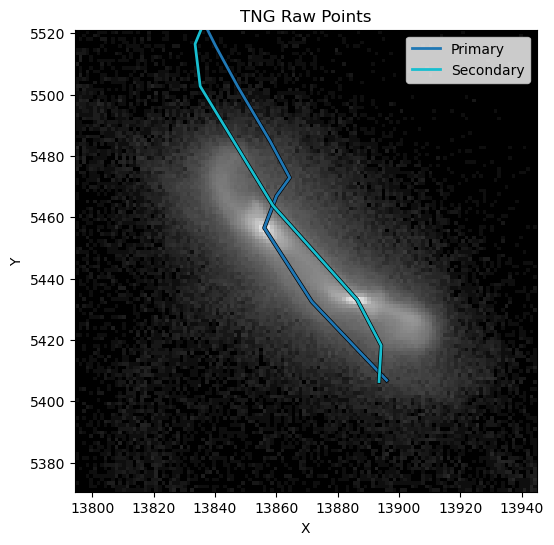

In [3]:
class TNG_Target_Class:

    def __init__(self, target_id, 
                 log_level = logging.INFO,
                 all_targets_loc = "/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl",
                 particle_dir = "/home/mbo2d/galStuff/data/tng-data/",
                 load_particles = True,):

        self.logger = gu.configure_logger( logger_name='tng_target_class', log_level=log_level )
        self.logger.info("Initializing TNG Target Data")
        
        self.target_id = target_id
        self.load_particles = load_particles

        # Extract target data from a file
        self.current_idx, self.state_history = self.extract_tng_target( self.target_id, all_targets_loc )

        # Set approximate inbound index (will calculate exact later)
        self.inbound_idx = self.current_idx - 2

        # Load particles if requested
        if self.load_particles:
            self.pts = self.load_pts_data( self.target_id, particle_dir )
        
        self.logger.info("Target Initalized")
    
    # Define a method to conveniently access the current state
    @property
    def current_state(self):
        return self.state_history.iloc[self.current_idx]
    
    # Define a method to conveniently access the inbound state (before MOCA)
    @property
    def inbound_state(self):
        return self.state_history.iloc[self.inbound_idx]

    # Cause it's helpful sometimes to print what I am    
    def __str__(self):
        return f"TNG_Target_Class: {self.name}"
    
    def set_log_level(self, log_level):
        self.logger.setLevel(log_level)
        
    def extract_tng_target(self, pid, subhalo_info_loc):

        self.logger.info(f"Extracting Target Data for: {self.target_id}")
        self.logger.debug(f"Looking in File: {subhalo_info_loc}")
        
        # Read the CSV file into a Pandas DataFrame
        try:
            all_tng_targets = pd.read_pickle(subhalo_info_loc, )
        except Exception as e:
            self.logger.error(f"Error loading file: {e}")
            raise

        # Ensure all the Target IDs are Int64
        for col in ['p_moi_1', 's_moi_1', 'moi_2', 'p_SubhaloIDRaw', 's_SubhaloIDRaw']:
            all_tng_targets[col] = all_tng_targets[col].astype('int64')
        
        # Get row with this p_SubhaloIDRaw
        t_row = all_tng_targets.loc[all_tng_targets['p_SubhaloIDRaw'] == pid]
        self.logger.debug("Pulled Data: %s"% str(type(t_row)))
        self.logger.debug("Pulled Size: %s"% str(t_row.shape))

        # Verify there's only one
        if len(t_row) != 1:
            self.logger.warning("Didn't find unique row for pid: %s - %s"%(str(pid), str(len(t_row))))   
            raise ValueError(f"Failed to find unique target for pid: {pid}")

        # Get the row
        t_row = t_row.iloc[0]

        # Get moi_2 id and grab all rows with this value
        m2_id = t_row['moi_2']
        t_df = all_tng_targets.loc[all_tng_targets['moi_2'] == m2_id].copy()
        t_df = t_df.sort_values('snap')  # Ensure df is sorted by snap
        t_df.reset_index(drop=True, inplace=True)  # Reset index
        self.logger.info( f"Loaded Data: {t_df.shape}")
        self.logger.debug( f"Snapshot Range: [ {t_df['snap'].min()} ... {t_df['snap'].max()} ]" )

        
        # Get index the t_row is in 
        t_row_index = t_df.index[t_df['p_SubhaloIDRaw'] == pid].tolist()[0]
        self.logger.debug(f"Row Index: {t_row_index}")

        return t_row_index, t_df

    def load_pts_data( self, pid, data_dir = '/home/mbo2d/data/tng-data/'):

        self.logger.info(f"Loading TNG Particles Data: {pid}")
        self.logger.debug(f"Data Directory: {data_dir}")

        # Find target particle location
        pid_file = f'pts_{pid}.npz'
        pid_path = os.path.join( data_dir, pid_file )
        self.logger.debug(f"PID File Found: {os.path.exists(pid_path)} - {pid_path}")

        try:
            data = np.load( pid_path )
            self.logger.debug(f"Data Loaded: {data.files}")
        except Exception as e:
            self.logger.error(f"Error Loading File: {pid_path} \n{e}")
            raise ValueError(f"Failed to load particle data for pid: {pid}")

        # Extract array from data
        pts_raw = data['array']
        self.logger.info(f"Particle Data: {pts_raw.shape}")
        
        return pts_raw

if buildEnv:

    logger.setLevel(logging.INFO)

    p1 = 62000000190717 
    p2 = 75000000317209 

    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )
    t2 = TNG_Target_Class( p2, load_particles = True, log_level=logging.INFO )
    p_path = np.vstack( t1.state_history['p_SubhaloPos_orbital_frame'] )
    print(f"Path: {type(p_path)} - {p_path.shape}")
    print( f"First Point: {p_path[0]}")

    i_start = 10
    plots_paths = [ np.vstack(t1.state_history['p_SubhaloPos'][i_start:]) ]
    plots_paths.append( np.vstack(t1.state_history['s_SubhaloPos'][i_start:]) )
    
    fig, ax = plt.subplots(1, 1, figsize=(6,6))

    tf.xy_histogram( 
        hist_data = t1.pts,
        plot_data = plots_paths, 
        plot_labels=['Primary','Secondary'], 
        title="TNG Raw Points", std_dev = 4, 
        ext_ax=ax, bins=128,
        show_labels=True,)

    # Save pts for later use
    pts1 = np.copy( t1.pts )

    del t1, t2

    if False:
        # ALL TARGET TEST (SUCCESS)
        target_list = os.listdir('/home/mbo2d/galStuff/data/tng-data/')
        target_list = [ int(x.split('_')[1].split('.')[0]) for x in target_list if 'pts' in x ]
        target_list.sort()

        print( f"Target List: {target_list}")

        for pid in target_list:
            try:
                t = TNG_Target_Class( pid, load_particles = True, log_level=logging.WARNING )
                print( f"Loaded Target: {pid} - {t.current_state['snap']} - {t.pts.shape}")
            except Exception as e:
                print( f"Failed to load target: {pid} - {e}")
                continue
        print( "All targets loaded...")
    
    

---
## Transform TNG Data to SPAM-like reference frame (Primary fixed at Origin)

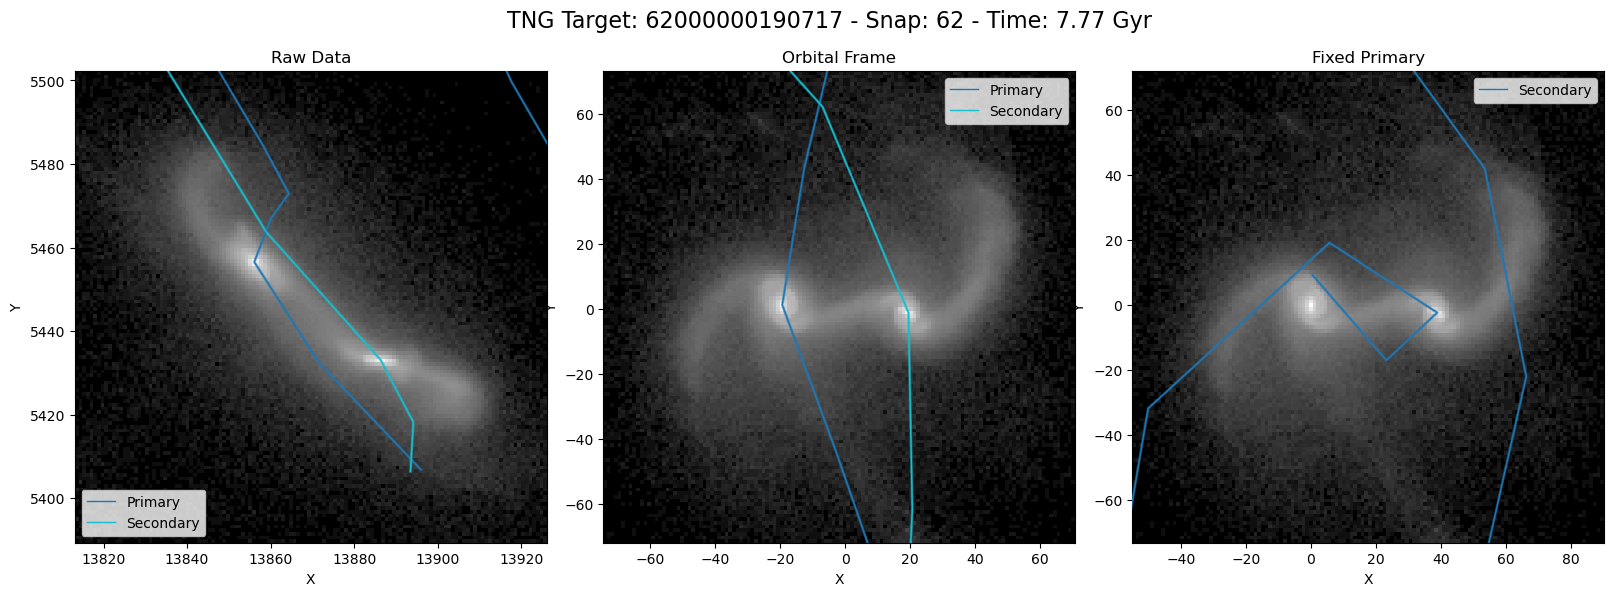

[2025-03-27 11:50:29,667 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:29,668 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717


[2025-03-27 11:50:30,045 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:30,060 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 11:50:30,768 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 11:50:30,769 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:30,770 - INFO - 4021226264._transform_tng_orbits]: Generating TNG Orbits: 62000000190717
[2025-03-27 11:50:31,480 - INFO - 4021226264.plot_orbit_pt_transforms]: Plotting Transforms of Orbit and Particle Data for: 62000000190717


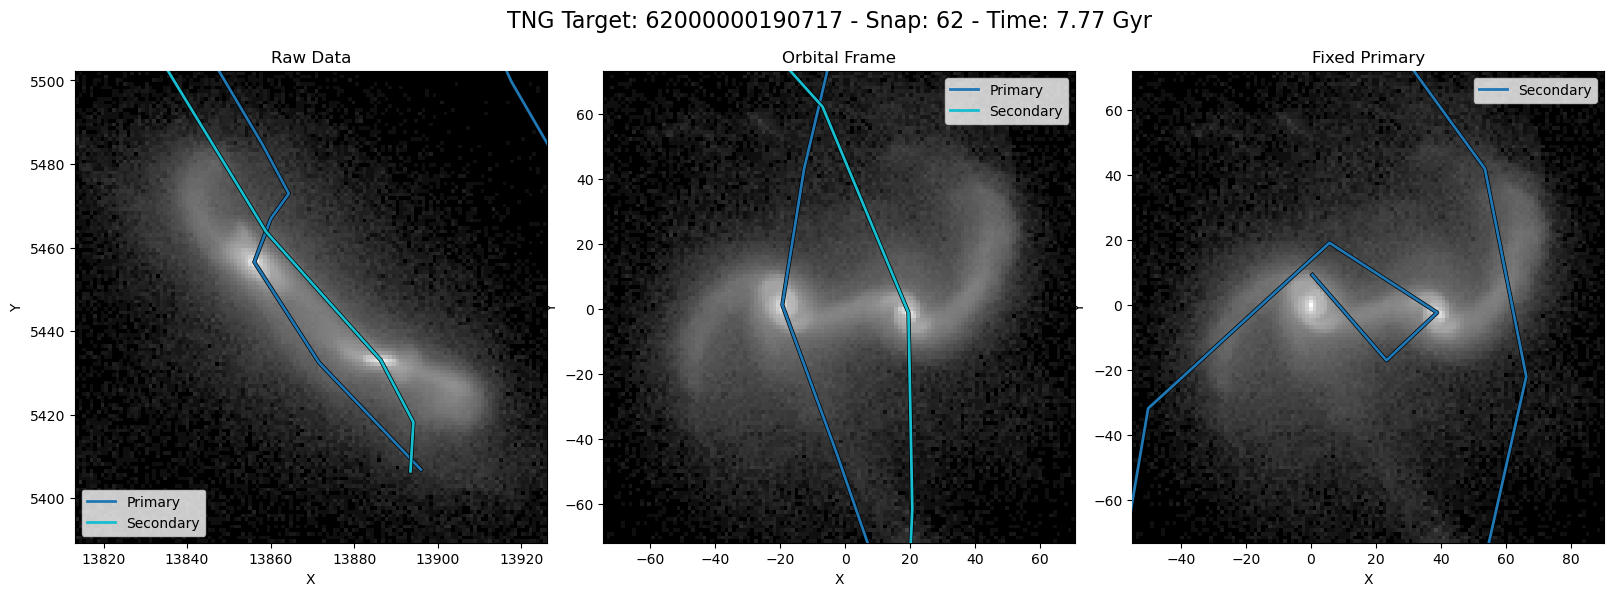

In [4]:
def transform_path_to_fixed_frame(self, primary, secondary):
    """
    Convert the orbital paths and velocities to a frame where the primary galaxy is fixed at the origin.

    Args:
    - primary (np.ndarray): Nx6 array of primary galaxy positions and velocities [ x y z vy vy vz ].
    - secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities [ x y z vy vy vz ].

    Returns:
    - fixed_secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary.shape == secondary.shape

    # Copy
    fixed_secondary = np.copy(secondary)

    # Move so primary is always at the origin for positions and velocities (Ignoring time if included)
    fixed_secondary[:,0:6] = secondary[:,0:6] - primary[:,0:6]
 
    return fixed_secondary
setattr( TNG_Target_Class, 'transform_path_to_fixed_frame', transform_path_to_fixed_frame )

def transform_path_to_moving_frame(self, primary_moving, secondary_fixed):
    """
    Convert the paths and velocities from a fixed primary frame back to the original moving frame.

    Args:
    - primary_moving (np.ndarray): Nx6 array of primary galaxy positions and velocities [x, y, z, vx, vy, vz].
    - secondary_fixed (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.

    Returns:
    - secondary_moving (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the moving frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary_moving.shape == secondary_fixed.shape, "Primary and fixed secondary arrays must have the same shape"

    # Convert to moving frame
    secondary_moving = secondary_fixed + primary_moving

    # If a 7th column, it's time and preserve it
    if secondary_fixed.shape[1] == 7:
        secondary_moving = np.hstack( [secondary_moving[:,0:6], secondary_fixed[:,6].reshape(-1,1)] )

    return secondary_moving
setattr( TNG_Target_Class, 'transform_path_to_moving_frame', transform_path_to_moving_frame )

def _transform_tng_orbits( self, skip_count=100 ):
    """
    Extract and convert the orbits for the TNG target data into various units and reference frames.
    1. Orginial TNG Units
    """

    self.logger.info(f"Generating TNG Orbits: {self.target_id}")
    log_n_lines = 2
    
    self.orbits = {}

    # Step 0) Retreive the starting data
    # 0.a Positions
    p_pos_raw = np.stack( self.state_history['p_SubhaloPos'].values )
    s_pos_raw = np.stack( self.state_history['s_SubhaloPos'].values )
    self.logger.debug( f"Primary Position Raw: {p_pos_raw.shape} \n{p_pos_raw[:log_n_lines]} \n... \n{p_pos_raw[-log_n_lines:]}" )
    self.logger.debug( f"Secondary Position Raw: {s_pos_raw.shape}\n {s_pos_raw[:log_n_lines]} \n... \n{s_pos_raw[-log_n_lines:]}" )
  
    # 0.b Velocities
    p_vel_raw = np.stack( self.state_history['p_SubhaloVel'].values )
    s_vel_raw = np.stack( self.state_history['s_SubhaloVel'].values )
    self.logger.debug( f"Primary Velocity Raw: {p_vel_raw.shape}\n {p_vel_raw[:log_n_lines]} \n... \n{p_vel_raw[-log_n_lines:]}" )
    self.logger.debug( f"Secondary Velocity Raw: {s_vel_raw.shape}\n {s_vel_raw[:log_n_lines]} \n... \n{s_vel_raw[-log_n_lines:]}" )

    # 0.c Time
    times = np.stack( self.state_history['time_gyr'].values ).reshape(-1,1)
    self.logger.debug( f"Times: {times.shape}\n {times[:log_n_lines]} \n... \n{times[-log_n_lines:]}" )

    # 0.d) Combine and store the raw data
    self.orbits['raw_primary'] = np.hstack( [p_pos_raw, p_vel_raw, times] )
    self.orbits['raw_secondary'] = np.hstack( [s_pos_raw, s_vel_raw, times] )
    if self.load_particles:
        self.orbits['raw_pts'] = np.copy(self.pts[::skip_count]) # Only store some for plotting purposes


    # Step 1) Transform/rotate the data 
    # 1.a) Get the transformation matrices
    pos_transform = self.current_state['orbital_frame_pos_transform']
    vel_transform = self.current_state['orbital_frame_vel_transform']
    self.logger.debug( f"Positional Transform: \n{pos_transform}" )
    self.logger.debug( f"Velocity Transform: \n{vel_transform}" )

    # 1.b) Apply the transformations to the data
    p_pos = tf.apply_transformation( pos_transform, p_pos_raw )
    s_pos = tf.apply_transformation( pos_transform, s_pos_raw )
    p_vel = tf.apply_transformation( vel_transform, p_vel_raw )
    s_vel = tf.apply_transformation( vel_transform, s_vel_raw )
    if self.load_particles:
        self.pts[:,0:3] = tf.apply_transformation( pos_transform, self.pts[:,0:3] )
        self.pts[:,3:6] = tf.apply_transformation( vel_transform, self.pts[:,3:6] )

    self.logger.debug( f"Transformed Primary Position: {p_pos.shape}\n {p_pos[:log_n_lines]}\n...\n{p_pos[-log_n_lines:]}" )
    self.logger.debug( f"Transformed Secondary Position: {s_pos.shape}\n {s_pos[:log_n_lines]}" )
    self.logger.debug( f"Transformed Primary Velocity: {p_vel.shape}\n {p_vel[:log_n_lines]}" )
    self.logger.debug( f"Transformed Secondary Velocity: {s_vel.shape}\n {s_vel[:log_n_lines]}" )

    # 1.c) Combine the orbit data into a single array
    p_path_moving = np.hstack( [p_pos, p_vel, times] )
    s_path_moving = np.hstack( [s_pos, s_vel, times] )
    self.orbits['tng_units_moving_frame_primary'] = p_path_moving
    self.orbits['tng_units_moving_frame_secondary'] = s_path_moving
    self.logger.debug( f"Moving Frame Primary Path: {p_path_moving.shape}\n {p_path_moving[:log_n_lines]} \n... \n{p_path_moving[-log_n_lines:]}" )
    self.logger.debug( f"Moving Frame Secondary Path: {s_path_moving.shape}\n {s_path_moving[:log_n_lines]} \n... \n{s_path_moving[-log_n_lines:]}" )
    
    # 1.d) Store the transformed paths
    self.orbits['orbital_primary'] = p_path_moving
    self.orbits['orbital_secondary'] = s_path_moving
    if self.load_particles:
        self.orbits['orbital_pts'] = np.copy(self.pts[::skip_count]) # Only store some for plotting purposes

    # Step 2) Tranform reference frame so Primary is constantly at origin.
    # 2.a) Convert to fixed frame
    path_fixed_tu = self.transform_path_to_fixed_frame( p_path_moving, s_path_moving )
    if self.load_particles:
        self.pts[:,0:3] = self.pts[:,0:3] - p_path_moving[ self.current_idx, 0:3 ]  # Move current state particles to fix primary at origin
    
    # 2.b) Store for plotting
    self.orbits['fixed_tu'] = path_fixed_tu
    if self.load_particles:
        self.orbits['fixed_tu_pts'] = np.copy(self.pts[::skip_count])
    self.logger.debug( f"Fixed Frame Path: {path_fixed_tu.shape}\n {path_fixed_tu[:log_n_lines]} \n... \n{path_fixed_tu[-log_n_lines:]}" )
setattr( TNG_Target_Class, '_transform_tng_orbits', _transform_tng_orbits )

def plot_orbit_pt_transforms( self ):
    """
    Plot the orbits and particle data for the TNG target as we transform between reference frames.
    """
    self.logger.info(f"Plotting Transforms of Orbit and Particle Data for: {self.target_id}")
    
    if not hasattr(self, 'orbits'):
        self._transform_tng_orbits()
    
    fig, ax = plt.subplots(1,3, figsize=(16,6))

    # Set Main title
    fig.suptitle(f"TNG Target: {self.target_id} - Snap: {self.current_state['snap']} - Time: {self.current_state['time_gyr']:.2f} Gyr", fontsize=16)

    bins = 128
    std_dev = 3
    fig.tight_layout(pad=1.0)

    tf.xy_histogram( 
        hist_data = self.orbits['raw_pts'],
        plot_data = [ self.orbits['raw_primary'], self.orbits['raw_secondary'] ],
        plot_labels=['Primary','Secondary'], 
        title="Raw Data", std_dev = std_dev, 
        ext_ax=ax[0], bins=bins, show_labels=True)
    
    tf.xy_histogram( 
        hist_data = self.orbits['orbital_pts'],
        plot_data = [ self.orbits['orbital_primary'], self.orbits['orbital_secondary'] ],
        plot_labels=['Primary','Secondary'], 
        title="Orbital Frame", std_dev = std_dev, 
        ext_ax=ax[1], bins=bins, show_labels=True)
    
    tf.xy_histogram( 
        hist_data = self.orbits['fixed_tu_pts'],
        plot_data = [ self.orbits['fixed_tu'] ],
        plot_labels=['Secondary'], 
        title="Fixed Primary", std_dev = std_dev, 
        ext_ax=ax[2], bins=bins, show_labels=True)
setattr( TNG_Target_Class, 'plot_orbit_pt_transforms', plot_orbit_pt_transforms )    

if buildEnv:
    tmp_t = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )
    # tmp_t.set_log_level(logging.DEBUG)
    tmp_t._transform_tng_orbits( skip_count=1)
    
    tmp_t.plot_orbit_pt_transforms()
    plt.show()

    # TEST ALL TARGETS
    break_at = 0
    if False:
        target_list = os.listdir('/home/mbo2d/galStuff/data/tng-data/')
        target_list = [ int(x.split('_')[1].split('.')[0]) for x in target_list if 'pts' in x ]
        target_list.sort()
        print( f"Target List: {target_list}")
        
        for i, pid in enumerate(target_list):
            try:
                t = TNG_Target_Class( pid, load_particles = True, log_level=logging.WARNING )
                t._transform_tng_orbits( skip_count = 1)
                t.plot_orbit_pt_transforms( )
                del t

            except Exception as e:
                print( f"Failed to load target: {pid} - {e}")
                continue

            if i> break_at: break

        print( "All targets loaded...")

___
# GLOBAL Constants

In [5]:
# ================================ CONSTANTS ================================ #

# Constants from Java code
G_NEWTON = 6.67430e-11         # Gravitational constant in m^3 kg^-1 s^-2
KG_PER_SOLAR_MASS = 1.98892e30   # Solar mass in kg
METERS_PER_PC = 3.08567758128e16   # Meters per parsec
SECONDS_PER_YEAR = 3.15576e7    # Seconds per year

# THESE ARE PULLED FROM JAVA CODE of SPAM
# Derived units for calculations
MU_kg = 1.0e11 * KG_PER_SOLAR_MASS  # 1e11 solar masses in kg
DU_m = 15.0 * 1000 * METERS_PER_PC  # 15 kpc in meters
TU_s = math.sqrt(DU_m * DU_m * DU_m / (G_NEWTON * MU_kg))  # Time unit in seconds (Based on Kepler's third law...?)

# SPAM standard units
spam_units = {

    # Mass unit - ( 10^11 solar masses )
    "mass_unit_solar_masses": 1e11,  # Mass unit in solar masses
    "mass_unit_kg": 1e11 * KG_PER_SOLAR_MASS,  # Mass unit in kg

    # Distance unit - ( 15 kpc )
    "distance_unit_kpc": 15.0,  # Distance unit in kiloparsecs
    "distance_units_pc": 15.0 * 1000,  # Distance unit in parsecs
    "distance_unit_m": 15.0 * 1000 * METERS_PER_PC ,  # Distance unit in meters

    # Time unit - ( roughly 85 Myr )
    "time_unit_s": None,  # To be calculated below

    # Velocity unit - ( roughly 170 km/s )
    "velocity_unit_m_per_s": None,  # To be calculated below
    "velocity_unit_km_per_s": None,  # To be calculated below

    # Acceleration unit
    "acceleration_unit_m_per_s2": None,  # To be calculated below

}

# Calculate time unit using Kepler's third law
spam_units["time_unit_s"] = math.sqrt(
    spam_units["distance_unit_m"] ** 3 / (G_NEWTON * spam_units["mass_unit_kg"])
)

# Calculate velocity unit (distance unit per time unit)
spam_units["velocity_unit_m_per_s"] = spam_units["distance_unit_m"] / spam_units["time_unit_s"]
spam_units["velocity_unit_km_per_s"] = spam_units["velocity_unit_m_per_s"] / 1000 # 1000 meters per kilometer

# Calculate acceleration unit (velocity unit per time unit)
spam_units["acceleration_unit_m_per_s2"] = spam_units["velocity_unit_m_per_s"] / spam_units["time_unit_s"]

# Dictionary of units for specific fields in the IllustrisTNG data
tng_units = {
    "mass_unit_solar_masses": 1e10,  # TNG Mass unit In solar units
    "mass_unit_kg": 1e10 * KG_PER_SOLAR_MASS,  # Convert kg to grams

    # Distance unit: 1 kpc in centimeters (comoving kiloparsecs per h)
    "distance_unit_kpc": 1.0,  # 1 kpc
    "distance_unit_pc" : 1e3, # 1 kpc in pc
    "distance_unit_m": 1e3 * METERS_PER_PC, # 1 kpc in meters

    # Velocity unit: 1 km/s in cm/s
    "velocity_unit_km_per_s": 1.0,

    # Time unit: 1 Gyr in seconds
    "time_unit_Gyr": 1.0,
    "time_unit_s": 1e9 * SECONDS_PER_YEAR,  # Convert Gyr to seconds
}

# Print comparing JAVA to Fortran units
if buildEnv:
    print("Mass Comparison: ")
    print("\t - Fortran (kg):", spam_units['mass_unit_kg'])
    print("\t - JAVA (kg):", MU_kg ) 

    print("Distance Comparison: ")
    print("\t - Fortran (m):", spam_units['distance_unit_m'])
    print("\t - JAVA (m):", DU_m )

    print("Time Comparison: ")
    print("\t - Fortran (s): %e" % spam_units['time_unit_s'])
    print("\t - JAVA (s): %e" % TU_s )

    print("\nValues are the same but in different units. \n")

# Dict linking index to SPAM Model parameter
spam_param_description = {
    0: 'X-coordinate of the secondary galaxy\'s position',
    1: 'Y-coordinate of the secondary galaxy\'s position',
    2: 'Z-coordinate of the secondary galaxy\'s position',
    3: 'X-component of the secondary galaxy\'s velocity',
    4: 'Y-component of the secondary galaxy\'s velocity',
    5: 'Z-component of the secondary galaxy\'s velocity',
    6: 'Mass of the primary galaxy',
    7: 'Mass of the secondary galaxy',
    8: 'Outer radius of the primary galaxy',
    9: 'Outer radius of the secondary galaxy',
    10: 'Azimuthal angle for the primary galaxy',
    11: 'Azimuthal angle for the secondary galaxy',
    12: 'Inclination angle for the primary galaxy',
    13: 'Inclination angle for the secondary galaxy',
    14: 'Softening length for the primary galaxy',
    15: 'Softening length for the secondary galaxy',
    16: 'Particle distribution of the primary galaxy',
    17: 'Particle distribution of the primary galaxy',
    18: 'Particle distribution of the primary galaxy',
    19: 'Particle distribution of the primary galaxy',
    20: 'Particle distribution of the secondary galaxy',
    21: 'Particle distribution of the secondary galaxy',
    22: 'Particle distribution of the secondary galaxy',
    23: 'Particle distribution of the secondary galaxy',
}


Mass Comparison: 
	 - Fortran (kg): 1.98892e+41
	 - JAVA (kg): 1.98892e+41
Distance Comparison: 
	 - Fortran (m): 4.62851637192e+20
	 - JAVA (m): 4.62851637192e+20
Time Comparison: 
	 - Fortran (s): 2.733073e+15
	 - JAVA (s): 2.733073e+15

Values are the same but in different units. 



___
# CORE FUNCTIONS
The following are the core functions needed to convert from TNG to SPAM.

___
## Convert data from TNG units to SPAM units

[2025-03-27 11:50:34,188 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:34,189 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717


[2025-03-27 11:50:34,487 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:34,503 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 11:50:35,225 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 11:50:35,227 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:35,227 - INFO - 3465369305._convert_tng_data_to_spam_units]: Converting TNG data to SPAM units for target: 62000000190717
[2025-03-27 11:50:35,228 - INFO - 4021226264._transform_tng_orbits]: Generating TNG Orbits: 62000000190717


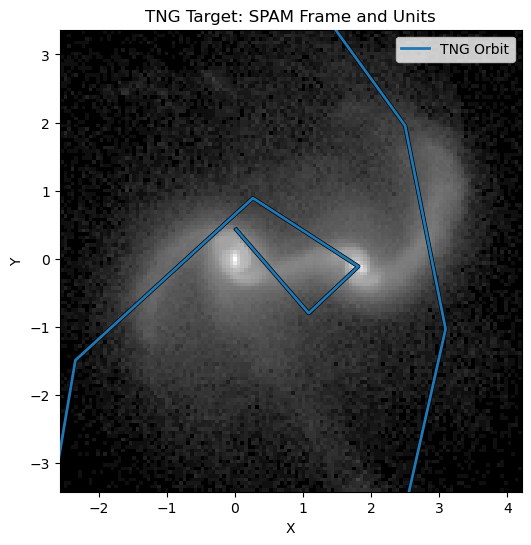

In [6]:
def convert_distance_tng_to_spam( self, tng_dist_ckpch, h=0.7):
    """
    Convert distances from TNG units (ckpc/h) to SPAM distance units.

    Parameters:
    - tng_dist_ckpch: Distance in comoving kiloparsecs per h (ckpc/h).
    - h: Hubble parameter.

    Returns:
    - spam_dist: Distance in SPAM units.
    """

    # Convert ckpc/h to ckpc (comoving kpc)
    dist_kpc = tng_dist_ckpch * h
    # Since we're working with "small scale" structures, use comoving distances as physical distances.

    # Convert ckpc to SPAM distance units (1 SPAM unit = 15 kpc)
    spam_dist = dist_kpc / spam_units["distance_unit_kpc"]
    return spam_dist
# End of convert_distance_tng_to_spam
setattr( TNG_Target_Class, 'convert_distance_tng_to_spam', convert_distance_tng_to_spam )

def convert_velocity_tng_to_spam( self, tng_vel_kms ):
    """
    Convert velocities from TNG units (km/s) to SPAM velocity units.

    Parameters:
    - tng_vel_kms: Velocity in km/s.

    Returns:
    - spam_vel: Velocity in SPAM units.
    """
    # Convert km/s to SPAM velocity units
    spam_vel = tng_vel_kms / spam_units["velocity_unit_km_per_s"]
    return spam_vel
# End of convert_velocity_tng_to_spam
setattr( TNG_Target_Class, 'convert_velocity_tng_to_spam', convert_velocity_tng_to_spam )

def convert_mass_tng_to_spam( self, tng_mass_1e10Msunh, h=0.7):
    """
    Convert masses from TNG units (1e10 M⊙/h) to SPAM mass units.

    Parameters:
    - tng_mass_1e10Msunh: Mass in units of 1e10 solar masses per h.
    - h: Hubble parameter.

    Returns:
    - spam_mass: Mass in SPAM units.
    """

    # Convert from 1e10 M⊙/h to M⊙
    mass_Msun = tng_mass_1e10Msunh * 1e10 * h

    # Convert M⊙ to SPAM mass units (1 SPAM unit = 1e11 M⊙)
    spam_mass = mass_Msun / spam_units["mass_unit_solar_masses"]
    return spam_mass
# End of convert_mass_tng_to_spam
setattr( TNG_Target_Class, 'convert_mass_tng_to_spam', convert_mass_tng_to_spam )

def convert_time_tng_to_spam( self, tng_time_Gyr):
    """
    Convert time from TNG units (Gyr) to SPAM time units.

    Parameters:
    - tng_time_Gyr: Time in Gigayears (Gyr).

    Returns:
    - spam_time: Time in SPAM units.
    """
    # Convert Gyr to seconds
    time_s = tng_time_Gyr * tng_units['time_unit_s']
    # Convert seconds to SPAM time units
    spam_time = time_s / spam_units["time_unit_s"]
    return spam_time
#   End of convert_time_tng_to_spam
setattr( TNG_Target_Class, 'convert_time_tng_to_spam', convert_time_tng_to_spam )

def _convert_tng_data_to_spam_units( self, skip_count=10 ):
    """
    Convert the TNG orbit and particle data to SPAM units.
    """

    self.logger.info(f"Converting TNG data to SPAM units for target: {self.target_id}")

    # Ensure the orbits have been transformed
    if not hasattr(self, 'orbits'):
        self._transform_tng_orbits()
    
    # Add column to state_history df
    self.state_history['time_su'] = self.convert_time_tng_to_spam( self.state_history['time_gyr'].values )

    # Convert the fixed frame from tng units to spam units
    self.orbits['fixed_su'] = np.copy(self.orbits['fixed_tu'])  # Copy the fixed frame data
    self.orbits['fixed_su'][:,0:3] = self.convert_distance_tng_to_spam( self.orbits['fixed_su'][:,0:3] )
    self.orbits['fixed_su'][:,3:6] = self.convert_velocity_tng_to_spam( self.orbits['fixed_su'][:,3:6] )
    self.orbits['fixed_su'][:,6] = self.convert_time_tng_to_spam( self.orbits['fixed_su'][:,6] )

    # Convert the particle data if loaded
    if self.load_particles:
        self.pts[:,0:3] = self.convert_distance_tng_to_spam( self.pts[:,0:3] )
        self.pts[:,3:6] = self.convert_velocity_tng_to_spam( self.pts[:,3:6] )
        self.orbits['fixed_su_pts'] = np.copy(self.pts[::skip_count])  # Only store some for plotting purposes
setattr( TNG_Target_Class, '_convert_tng_data_to_spam_units', _convert_tng_data_to_spam_units )

# Example usage
if buildEnv:
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )
    t1._convert_tng_data_to_spam_units()

    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    tf.xy_histogram( 
        hist_data = t1.pts,
        plot_data = [ t1.orbits['fixed_su'] ], 
        plot_labels=['TNG Orbit'], 
        title="TNG Target: SPAM Frame and Units", std_dev = 3, 
        ext_ax=ax, bins=128,
        show_labels=True, )


___
## Standardize SPAM-like Collision Parameter Array

In [7]:
def calculate_orientation_angles( spin ):
    """
    Calculate the azimuthal and inclination angles from the spin components.

    Parameters:
    spin (float array): [ x, y, z ] components of the spin.

    Returns:
    tuple: (phi, theta) where phi is the azimuthal angle and theta is the inclination angle,
            both in radians.
    """
    x, y, z = spin
    # Calculate the magnitude of the vector
    r = np.sqrt(x**2 + y**2 + z**2)

    # Calculate the azimuthal angle in radians
    phi = np.arctan2(y, x)  # This returns the angle in the range [-pi, pi]

    # Calculate the inclination angle in radians
    if r == 0:
        theta = 0  # Undefined direction for a zero vector, set arbitrarily to 0
    else:
        theta = np.arccos(z / r)

    return np.degrees(phi), np.degrees(theta)

def standardize_collision_parameters_v1( self, subhalo_kinematics, radius_scale=5.0, softening_scale = 0.1 ):
    """
    Construct a SPAM-like standardized collision parameter array from IllustrisTNG Subhalo kinetic data.
    Assumes all the information is pulled from the same snapshot/moment in time.  

    Args:
        subhalo_kinematics (pd.Series): The dynamic kinematic data calculated elsewhere.

    Returns:
        param_array (np.array): A standardized parameter array based on the SPAM simulator.
    """

    self.logger.info("Standardizing TNG parameters...")
    self.logger.debug("Radius Scale: %s", radius_scale)

    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # Position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        tng_ar[i] = subhalo_kinematics['s_SubhaloPos_orbital_frame'][i] - subhalo_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = subhalo_kinematics['ss_SubhaloVel_orbital_frame'][i] - subhalo_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # Masses, using total mass
    tng_ar[6] = subhalo_kinematics['pa_SubhaloMass']
    tng_ar[7] = subhalo_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * subhalo_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * subhalo_kinematics['ss_SubhaloHalfmassRad']

    # Orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( subhalo_kinematics['ps_SubhaloSpin_orbital_frame'] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( subhalo_kinematics['ss_SubhaloSpin_orbital_frame'] )

    # Just use a scale of previously radius value
    # Is the inner radius of stars SPAM will simulate.
    tng_ar[14] = tng_ar[8] * softening_scale
    tng_ar[15] = tng_ar[9] * softening_scale

    # Unknown purpose at this time...
    tng_ar[16:22] = np.zeros(6)

    return tng_ar
setattr( TNG_Target_Class, 'standardize_collision_parameters_v1', standardize_collision_parameters_v1 )

def standardize_collision_parameters_v2( self, inbound_snap, radius_scale=5.0, softening_scale = 0.1):
    """
    Similar to v1, but compiles data from different snapshots.  
    Because several kinematic values change over time (such as radius, mass exchange, etc.)
    This function is designed to take the current snapshot and the inbound snapshot
    to calculate the SPAM-like standardized collision parameter array from IllustrisTNG Subhalo kinetic data.

    Args:
        subhalo_df (pd.DataFrame): The dynamic kinematic data calculated over time
        current_snap (int): The snapshot number at the current moment
        inbound_snap (int): The snapshot number inbound to the moment of closest approach

    Returns:
        tng_ar (np.array): A standardized parameter array based on the SPAM simulator.
    """

    self.logger.info("Standardizing TNG parameters v2...")
    self.logger.debug("Inbound Snap: %d", inbound_snap)
    self.logger.debug("Radius Scale: %s", radius_scale)
    self.logger.debug("Softening Scale: %s", softening_scale)

    subhalo_df = self.state_history
    current_snap = self.current_state['snap']


    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # Get current row
    current_kinematics = subhalo_df[ subhalo_df['snap'] == current_snap ].iloc[0]  

    # Get row for inbound_n snapshots
    inbound_kinematics = subhalo_df[ subhalo_df['snap'] == inbound_snap ].iloc[0]

    # position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        # tng_ar[i] = subhalo_kinematics['ss_SubhaloCM'][i] - subhalo_kinematics['ps_SubhaloCM'][i]  # position
        tng_ar[i] = current_kinematics['s_SubhaloPos_orbital_frame'][i] - current_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = current_kinematics['ss_SubhaloVel_orbital_frame'][i] - current_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # masses, use inbound masses in case they've changed in the inbound_n snapshots
    tng_ar[6] = inbound_kinematics['pa_SubhaloMass']
    tng_ar[7] = inbound_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * inbound_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * inbound_kinematics['ss_SubhaloHalfmassRad']

    # orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( tf.apply_transformation( current_kinematics['orbital_frame_vel_transform'], np.reshape( inbound_kinematics['ps_SubhaloSpin'], (1,-1) ),  )[0] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( tf.apply_transformation( current_kinematics['orbital_frame_vel_transform'], np.reshape( inbound_kinematics['ss_SubhaloSpin'], (1,-1) ),  )[0] )

    # Just use a scale of previously radius value. 
    # For inner radius of stars SPAM will simulate.
    tng_ar[14] = tng_ar[8] * softening_scale
    tng_ar[15] = tng_ar[9] * softening_scale

    # Use 0 for now.  Purpose unknown.
    tng_ar[16:22] = np.zeros(6)

    return tng_ar
setattr( TNG_Target_Class, 'standardize_collision_parameters_v2', standardize_collision_parameters_v2 )

def convert_collision_parameters_tng_to_spam_units( self, tng_ar, h=0.7):
    """
    Convert IllustrisTNG data to SPAM units.

    Parameters:
    - tng_ar: numpy array, array of targets in IllustrisTNG units.
        Expected indices:
        [0-2]: Positions (ckpc/h)
        [3-5]: Velocities (km/s)
        [6-7]: Masses (1e10 M⊙/h)
        [8-9]: Radii (ckpc/h)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (ckpc/h)
    - h: float, the Hubble parameter used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - spam_data: numpy array, target converted to SPAM units.
    """
    self.logger.info("Converting TNG units to SPAM units...")

    # Initialize spam data array
    spam_data = np.zeros(22)

    # Convert Positions (indices 0-2)
    spam_data[0:3] = self.convert_distance_tng_to_spam(tng_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    spam_data[3:6] = self.convert_velocity_tng_to_spam(tng_ar[3:6])

    # Convert Masses (indices 6-7)
    spam_data[6:8] = self.convert_mass_tng_to_spam(tng_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    spam_data[8:10] = self.convert_distance_tng_to_spam(tng_ar[8:10], h)
    spam_data[14:16] = self.convert_distance_tng_to_spam(tng_ar[14:16], h)

    # Use same orientation angles (indices 10-13)
    spam_data[10:14] = tng_ar[10:14]

    # Remaining indices (16-21) are unused or set to zero
    spam_data[16:] = 0.0

    return spam_data
# End of convert_units_tng_to_spam
setattr( TNG_Target_Class, 'convert_collision_parameters_tng_to_spam_units', convert_collision_parameters_tng_to_spam_units )

def _gen_spam_collision_parameters( self, radius_scale = 5.0, softening_scale = 0.1):
    """
    Generate the SPAM-like collision parameters from the TNG data.
    """

    self.logger.info(f"Generating SPAM collision parameters for target: {self.target_id}")

    tng_ar = self.standardize_collision_parameters_v2( self.inbound_state['snap'], radius_scale=radius_scale, softening_scale=softening_scale )
    self.logger.debug( f"Standardized TNG parameters: {tng_ar}" )

    self.spam_ar = self.convert_collision_parameters_tng_to_spam_units( tng_ar )
    self.logger.debug( f"Converted SPAM parameters: {self.spam_ar}" )
setattr( TNG_Target_Class, '_gen_spam_collision_parameters', _gen_spam_collision_parameters )

if buildEnv:
    t1 = TNG_Target_Class( p1, load_particles = False, log_level=logging.INFO )
    t1.set_log_level( logging.DEBUG )

    t1.tng_ar1 = t1.standardize_collision_parameters_v1( t1.current_state )
    t1.tng_ar = t1.standardize_collision_parameters_v2( t1.inbound_state['snap'] )
    t1._gen_spam_collision_parameters( )

    print( "\nPercent Difference between v1 and v2: ")
    print(f" i:  tng_ar   -   (% diff)   - Index Description")
    print(f"---------------------------------------------")
    for i in range( len( t1.tng_ar ) ):
        if t1.tng_ar[i] == 0:
            p_diff = 0
        else:
            p_diff = 100 * ( t1.tng_ar[i] - t1.tng_ar1[i] ) / t1.tng_ar[i]

        # print in pretty format
        print( f"{i:2d}: {t1.spam_ar[i]:+.2e} - ({p_diff:+.1e} %) - {spam_param_description[i]}" )
    

[2025-03-27 11:50:36,469 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:36,470 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717


[2025-03-27 11:50:36,690 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:36,701 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:36,704 - INFO - 1494702708.standardize_collision_parameters_v1]: Standardizing TNG parameters...
[2025-03-27 11:50:36,705 - DEBUG - 1494702708.standardize_collision_parameters_v1]: Radius Scale: 5.0
[2025-03-27 11:50:36,707 - INFO - 1494702708.standardize_collision_parameters_v2]: Standardizing TNG parameters v2...
[2025-03-27 11:50:36,707 - DEBUG - 1494702708.standardize_collision_parameters_v2]: Inbound Snap: 60
[2025-03-27 11:50:36,708 - DEBUG - 1494702708.standardize_collision_parameters_v2]: Radius Scale: 5.0
[2025-03-27 11:50:36,709 - DEBUG - 1494702708.standardize_collision_parameters_v2]: Softening Scale: 0.1
[2025-03-27 11:50:36,712 - INFO - 1494702708._gen_spam_collision_parameters]: Generating SPAM collision parameters for target: 62000000190717
[2025-03-27 11:50:36,713 - INFO - 1494702708.standar


Percent Difference between v1 and v2: 
 i:  tng_ar   -   (% diff)   - Index Description
---------------------------------------------
 0: +1.81e+00 - (+0.0e+00 %) - X-coordinate of the secondary galaxy's position
 1: -1.10e-01 - (-0.0e+00 %) - Y-coordinate of the secondary galaxy's position
 2: +1.80e-08 - (+0.0e+00 %) - Z-coordinate of the secondary galaxy's position
 3: +8.99e-02 - (+0.0e+00 %) - X-component of the secondary galaxy's velocity
 4: -6.00e-01 - (-0.0e+00 %) - Y-component of the secondary galaxy's velocity
 5: -1.25e-01 - (-0.0e+00 %) - Z-component of the secondary galaxy's velocity
 6: +7.81e+00 - (-7.2e+00 %) - Mass of the primary galaxy
 7: +9.87e-01 - (+2.2e+01 %) - Mass of the secondary galaxy
 8: +9.37e-01 - (-2.7e+01 %) - Outer radius of the primary galaxy
 9: +1.15e+00 - (-9.0e+00 %) - Outer radius of the secondary galaxy
10: +5.22e+01 - (-5.1e+01 %) - Azimuthal angle for the primary galaxy
11: +1.23e+02 - (-1.3e+01 %) - Azimuthal angle for the secondary galaxy


___
## Convert data from SPAM units to TNG units

In [8]:
def convert_distance_spam_to_tng(self, spam_dist, h=0.7):
    """
    Convert distances from SPAM units back to TNG units (ckpc/h).

    Parameters:
    - spam_dist: Distance in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_dist_ckpch: Distance in ckpc/h.
    """
    # Convert SPAM units to ckpc
    dist_ckpc = spam_dist * spam_units["distance_unit_kpc"]
    # Convert ckpc to ckpc/h
    tng_dist_ckpch = dist_ckpc / h
    return tng_dist_ckpch
setattr( TNG_Target_Class, 'convert_distance_spam_to_tng', convert_distance_spam_to_tng )

def convert_velocity_spam_to_tng(self, spam_vel):
    """
    Convert velocities from SPAM units back to TNG units (km/s).

    Parameters:
    - spam_vel: Velocity in SPAM units.

    Returns:
    - tng_vel_kms: Velocity in km/s.
    """
    # Convert SPAM velocity units to km/s
    tng_vel_kms = spam_vel * spam_units["velocity_unit_km_per_s"]
    return tng_vel_kms
setattr( TNG_Target_Class, 'convert_velocity_spam_to_tng', convert_velocity_spam_to_tng )

def convert_mass_spam_to_tng(self, spam_mass, h=0.7):
    """
    Convert masses from SPAM units back to TNG units (1e10 M⊙/h).

    Parameters:
    - spam_mass: Mass in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_mass_1e10Msunh: Mass in units of 1e10 M⊙/h.
    """
    # Convert SPAM mass units to solar masses
    mass_Msun = spam_mass * spam_units["mass_unit_solar_masses"]
    # Convert solar masses to 1e10 M⊙/h units
    tng_mass_1e10Msunh = (mass_Msun / (1e10 * h))
    return tng_mass_1e10Msunh
setattr( TNG_Target_Class, 'convert_mass_spam_to_tng', convert_mass_spam_to_tng )

def convert_time_spam_to_tng(self, spam_time):
    """
    Convert time from SPAM units back to TNG units (Gyr).

    Parameters:
    - spam_time: Time in SPAM units.

    Returns:
    - tng_time_Gyr: Time in Gigayears (Gyr).
    """
    # Convert SPAM time units to seconds
    time_s = spam_time * spam_units["time_unit_s"]
    # Convert seconds to Gyr
    tng_time_Gyr = time_s / tng_units['time_unit_s']
    return tng_time_Gyr
setattr( TNG_Target_Class, 'convert_time_spam_to_tng', convert_time_spam_to_tng )

def convert_collision_parameters_spam_to_tng_units(self, spam_ar, h=0.7):
    """
    Convert SPAM data back to IllustrisTNG units.

    Parameters:
    - spam_ar: numpy array, array of data in SPAM units.
        Expected indices:
        [0-2]: Positions (SPAM units)
        [3-5]: Velocities (SPAM units)
        [6-7]: Masses (SPAM units)
        [8-9]: Radii (SPAM units)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (SPAM units)
        [16-21]: Additional parameters (unused or zeros)
    - h: float, the Hubble constant used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - tng_data: numpy array, data converted back to TNG units.
    """
    logger.info("Converting SPAM units to TNG units...")   
    # Initialize tng data array
    tng_data = np.zeros_like(spam_ar)

    # Convert Positions (indices 0-2)
    tng_data[0:3] = self.convert_distance_spam_to_tng(spam_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    tng_data[3:6] = self.convert_velocity_spam_to_tng(spam_ar[3:6])

    # Convert Masses (indices 6-7)
    tng_data[6:8] = self.convert_mass_spam_to_tng(spam_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    tng_data[8:10] = self.convert_distance_spam_to_tng(spam_ar[8:10], h)
    tng_data[14:16] = self.convert_distance_spam_to_tng(spam_ar[14:16], h)

    # Copy Orientation Angles (indices 10-13)
    tng_data[10:14] = spam_ar[10:14]

    # Remaining indices (16-21) are unused or zeros
    tng_data[16:] = spam_ar[16:]

    return tng_data
setattr( TNG_Target_Class, 'convert_collision_parameters_spam_to_tng_units', convert_collision_parameters_spam_to_tng_units )

# Example usage
if buildEnv:
    
    tmp_class = TNG_Target_Class( p1, load_particles = False, log_level=logging.INFO )
    
    t1.tng_ar = t1.standardize_collision_parameters_v2( t1.inbound_state['snap'] )
    t1.spam_ar = t1.convert_collision_parameters_spam_to_tng_units( t1.tng_ar )
    t1.tng_back = t1.convert_collision_parameters_tng_to_spam_units( t1.spam_ar )
    print( "\nPercent Error between tng_ar and spam_ar: ")
    
    error_sum = np.sum( np.abs( t1.tng_ar - t1.tng_back ) )
    print( f"Error Sum: {error_sum:.3f}\n" )

    # for i in range( len( t1.tng_back ) ):
    #     print(f"{i:2d}:\t{t1.tng_ar[i]:+.2e}\t{t1.tng_back[i]:+.2e} \t- {spam_param_description[i]}")

[2025-03-27 11:50:36,758 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:36,759 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717


[2025-03-27 11:50:37,270 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:37,287 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:37,289 - INFO - 1494702708.standardize_collision_parameters_v2]: Standardizing TNG parameters v2...
[2025-03-27 11:50:37,292 - INFO - 3107245448.convert_collision_parameters_spam_to_tng_units]: Converting SPAM units to TNG units...
[2025-03-27 11:50:37,293 - INFO - 1494702708.convert_collision_parameters_tng_to_spam_units]: Converting TNG units to SPAM units...



Percent Error between tng_ar and spam_ar: 
Error Sum: 0.000



____
## Generate Interpolation Splines of TNG Orbit

So, I want to study the TNG orbit between snapshots, specifically the moments of closest approach aka fly-by events.  Splines are a common way to interpolate between points, so let's create a spline for the TNG data. 


[2025-03-27 11:50:37,324 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:37,325 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717


[2025-03-27 11:50:37,598 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:37,613 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 11:50:38,412 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 11:50:38,413 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:38,414 - INFO - 3465369305._convert_tng_data_to_spam_units]: Converting TNG data to SPAM units for target: 62000000190717
[2025-03-27 11:50:38,415 - INFO - 4021226264._transform_tng_orbits]: Generating TNG Orbits: 62000000190717
[2025-03-27 11:50:39,171 - INFO - 1317353494._gen_splines_hermite]: Interpolating path with Hermite cubic splines...
[2025-03-27 11:50:39,178 - INFO - 1317353494._gen_splines_natural_cubic]: Interpolating path with natural cubic splines...


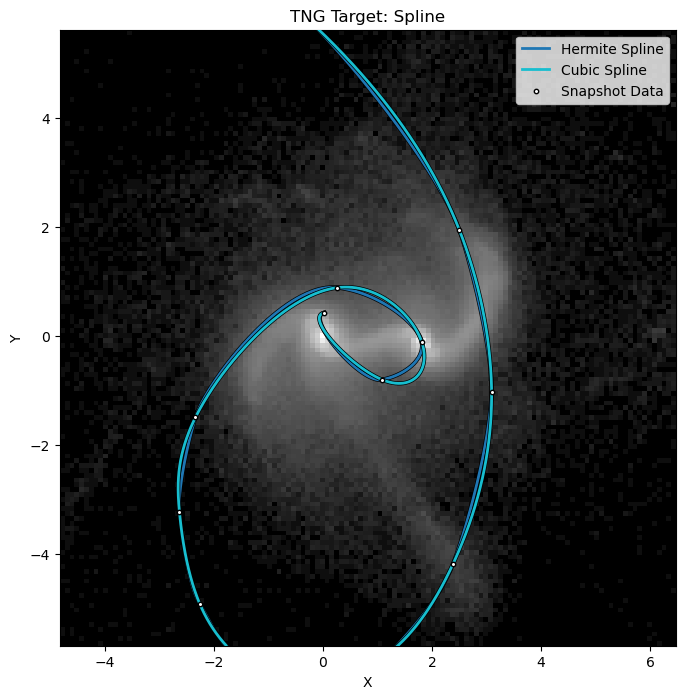

In [9]:
from scipy.interpolate import CubicSpline, CubicHermiteSpline

# These functions are used to generate splines for the path of the secondary galaxy
def _gen_splines_natural_cubic(self, times, path):

    self.logger.info("Interpolating path with natural cubic splines...")

    # Extract positions and velocities
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create cubic splines with clamped boundary conditions using endpoint velocities
    spline_x = CubicSpline(times, x, bc_type=((1, dx[0]), (1, dx[-1])))
    spline_y = CubicSpline(times, y, bc_type=((1, dy[0]), (1, dy[-1])))
    spline_z = CubicSpline(times, z, bc_type=((1, dz[0]), (1, dz[-1])))

    # Add the splines and their derivative functions to a list
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines
setattr( TNG_Target_Class, '_gen_splines_natural_cubic', _gen_splines_natural_cubic )

def _gen_splines_hermite(self, times, path):

    self.logger.info("Interpolating path with Hermite cubic splines...")

    # Separate positions and velocities into x, y, z components
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create Hermite splines for each dimension
    spline_x = CubicHermiteSpline(times, x, dx)
    spline_y = CubicHermiteSpline(times, y, dy)
    spline_z = CubicHermiteSpline(times, z, dz)

    # Create list of splines and their derivative functions
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines
setattr( TNG_Target_Class, '_gen_splines_hermite', _gen_splines_hermite )

def _gen_target_spline_data( self, spline_type = 'hermite', sample_times = None ):
    """
    Generate the spline for the orbit of the secondary galaxy in SPAM frame and units

    Parameters:
    - spline_type: str, type of spline to use ('natural_cubic' or 'hermite').

    Returns:
    - splines: list, list of splines for x, y, z positions and their derivatives.
    """

    if not hasattr(self, 'orbits'):
        self._transform_tng_orbits()
    
    if self.orbits.get('fixed_su') is None:
        self._convert_tng_data_to_spam_units()

    # Create dictionary to hold spline related data
    self.spline = {}

    # Generate the spline functions
    if spline_type == 'natural_cubic':
        self.spline['functions'] = self._gen_splines_natural_cubic(self.orbits['fixed_su'][:, 6], self.orbits['fixed_su'])
    elif spline_type == 'hermite':
        self.spline['functions'] = self._gen_splines_hermite(self.orbits['fixed_su'][:, 6], self.orbits['fixed_su'])
    
    # Generate sample times if not provided
    if sample_times is None:
        n = 10000
        sample_times = np.linspace(self.orbits['fixed_su'][0, 6], self.orbits['fixed_su'][-1, 6], n)
    
    # Generate sample data
    sample_path = np.zeros((len(sample_times), 7))
    for i,s in enumerate(self.spline['functions']): 
        sample_path[:, i] = s(sample_times)     # Position and velocities
    sample_path[:, 6] = sample_times # Times

    # Store for later ues
    self.spline['orbit'] = sample_path
setattr( TNG_Target_Class, '_gen_target_spline_data', _gen_target_spline_data )

if buildEnv:
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )
    t1._convert_tng_data_to_spam_units()
    t1._gen_target_spline_data( spline_type = 'hermite' )
    
    # Save spline for comparison
    hermite_sample = np.copy( t1.spline['orbit'] )

    # Gen new spline
    t1._gen_target_spline_data( spline_type = 'natural_cubic' )
    cubic_sample = np.copy( t1.spline['orbit'] )
    
    fig, ax = plt.subplots(1, 1, figsize=(8,8))

    tf.xy_histogram(
        hist_data = t1.pts,
        plot_data = [ hermite_sample, cubic_sample ],
        plot_labels = ['Hermite Spline', 'Cubic Spline'],
        scatter_data = [ ( t1.orbits['fixed_su'], "Snapshot Data" ) ],
        title="TNG Target: Spline", std_dev = 5, 
        ext_ax=ax, bins=128,
        show_labels=True, 
    )


## Analysing Splines

According to ChatGPT, Hermites require positions and velocities to be perfect matches, but this makes the curve look unnatural to me, like it's focusing on connecting dots. It might be using abrupt changes in accelatation to accomplish this.  Natural cubic's on the other hand, do their best to minimize acceleration and thus smooths velocity and acceleration.  Which makes it look intuitively smoother but it does make the spline less accurate.

Thankfully, while directly comparing the Hermite and natural spline, there does not appear to be any large differences in position/velocity (Except at the very end when they merge, and accelerations are crazy.  Which is not a focus).  And given the spline is an interpolation in the first place, there will always be a bit of error between points no matter which inpertoloation I use.

**(NO MORE SPLINES MATTHEW)**

___
# Generate Moment of Closest Approach (MOCA) Data

Given a lot of literature mentions the moment of closest approach (henceforth MOCA in code), we want to characterize some of the data around that particular moment. 

[2025-03-27 11:50:40,242 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:40,243 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717
[2025-03-27 11:50:40,634 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:40,648 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 11:50:41,411 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 11:50:41,412 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:41,414 - INFO - 3465369305._convert_tng_data_to_spam_units]: Converting TNG data to SPAM units for target: 62000000190717
[2025-03-27 11:50:41,415 - INFO - 4021226264._transform_tng_orbits]: Generating TNG Orbits: 62000000190717
[2025-03-27 11:50:41,915 - INFO - 1317353494._gen_splines_hermite]: Interpolating path with Hermite cubic splines...
[2025-03-27 11:50:41,919 - INFO - 3885842407._gen_moment_of_closest_approach]: Genera

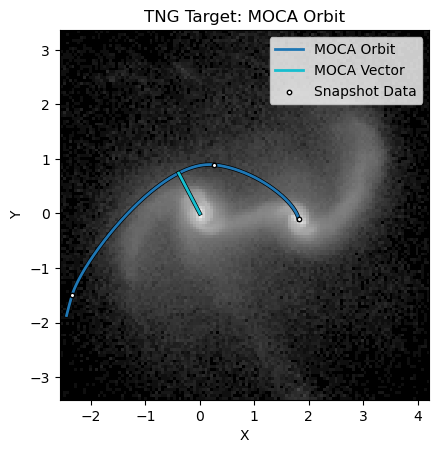

In [10]:
def _gen_moment_of_closest_approach(self):
    
    """
    Generate information surrounding the most recent moment of closest approach.
    MOCA: Moment-Of-Closest-Approach
    """

    self.logger.info("Generating Most Recent Moment of Closest Approach (MOCA) Info...")
    self.moca = {} # Moment Of Closest Approach

    # Get Info for current state (after MOCA) 
    # Using spline for consistency. 
    self.moca['current'] = {}
    self.moca['current']['idx'] = np.argmin( np.abs( self.spline['orbit'][:,-1] - self.current_state['time_su'] ) ) 
    self.moca['current']['pos'] = self.spline['orbit'][ self.moca['current']['idx'], 0:3 ]
    self.moca['current']['time_su'] = self.spline['orbit'][ self.moca['current']['idx'], -1 ]
    self.moca['current']['time_tu'] = self.convert_time_spam_to_tng( self.moca['current']['time_su'] ) 
    
    self.logger.debug( f"Current Spline idx: {self.moca['current']['idx']}" )
    self.logger.debug( f"Current Spline Info: {self.spline['orbit'][ self.moca['current']['idx'] ]}" )
    self.logger.debug( f"Current Target - Pos: {self.orbits['fixed_su'][self.current_idx, 0:3]}" )
    self.logger.debug( f"Current Spline - Pos: {self.moca['current']['pos']}" )
    self.logger.debug( f"Current Time SU: {self.moca['current']['time_su']:.2f} SU" )
    self.logger.debug( f"Current Time TNG: {self.moca['current']['time_tu']:.2f} Gy - Snap: { self.current_state['snap']}" )

    # Find index of spline where orbit is closest to the primary galaxy (origin) before current time
    seperation_dist = np.linalg.norm( self.spline['orbit'][:,0:3], axis = 1 )
    minima = argrelextrema( seperation_dist, np.less, order=5 )
    closest_idx = minima[0][ minima[0] < self.moca['current']['idx'] ][-1]

    # Get the closest approach info
    self.moca['closest'] = {}
    self.moca['closest']['idx'] = closest_idx
    self.moca['closest']['pos'] = self.spline['orbit'][closest_idx,0:3]
    self.moca['closest']['time_su'] = self.spline['orbit'][closest_idx,-1]
    self.moca['closest']['time_tu'] = self.convert_time_spam_to_tng( self.moca['closest']['time_su'] )

    self.logger.debug( f"Closest Spline idx: {self.moca['closest']['idx']}" )
    self.logger.debug( f"Closest Spline Info: {self.spline['orbit'][ self.moca['closest']['idx'] ]}" )
    self.logger.debug( f"Closest Pos: {self.moca['closest']['pos']}" )
    self.logger.debug( f"Closest Time SU: {self.moca['closest']['time_su']:.2f} SU" )
    self.logger.debug( f"Closest Time TNG: {self.moca['closest']['time_tu']:.2f} Gy" )

    # Get opposite inbound boundary from current time centered on closest time
    diff_idx = self.moca['current']['idx'] - self.moca['closest']['idx']

    self.moca['inbound'] = {}
    self.moca['inbound']['idx'] = self.moca['closest']['idx'] - diff_idx
    self.moca['inbound']['pos'] = self.spline['orbit'][ self.moca['inbound']['idx'], 0:3 ]
    self.moca['inbound']['time_su'] = self.spline['orbit'][ self.moca['inbound']['idx'], -1 ]
    self.moca['inbound']['time_tu'] = self.convert_time_spam_to_tng( self.moca['inbound']['time_su'] )

    self.logger.debug( f"Inbound Spline idx: {self.moca['inbound']['idx']}" )
    self.logger.debug( f"Inbound Spline Info: {self.spline['orbit'][ self.moca['inbound']['idx'] ]}" )
    self.logger.debug( f"Inbound Pos: {self.moca['inbound']['pos']}" )
    self.logger.debug( f"Inbound Time SU: {self.moca['inbound']['time_su']:.2f} SU" )
    self.logger.debug( f"Inbound Time TNG: {self.moca['inbound']['time_tu']:.2f} Gy" )

    # Get subsection of spline orbit that captures this window
    self.moca['orbit'] = self.spline['orbit'][ self.moca['inbound']['idx'] : self.moca['current']['idx']+1 ]
    self.moca['vector'] = np.vstack( [ [0,0], [self.moca['closest']['pos'][0:2]] ] )
    self.moca['inbound']['idx'] = 0
    self.moca['closest']['idx'] = self.moca['closest']['idx'] - self.moca['inbound']['idx']
    self.moca['current']['idx'] = self.moca['current']['idx'] - self.moca['inbound']['idx']

    self.logger.debug( f"MOCA Orbit: {self.moca['orbit'].shape}\n{self.moca['orbit'][:2]}\n...\n{self.moca['orbit'][-2:]}" )
    self.logger.debug( f"MOCA Idx: {self.moca['inbound']['idx']} - {self.moca['closest']['idx']} - {self.moca['current']['idx']}" )

    # Lastly, Get Snapshot from before the inbound time
    self.inbound_idx = len( self.state_history['time_su'][ self.state_history['time_su'] < self.moca['inbound']['time_su']] ) - 1

    self.logger.debug( f"MOCA Inbound Idx: {self.inbound_idx} - Snap: {self.inbound_state['snap']}" )
setattr( TNG_Target_Class, '_gen_moment_of_closest_approach', _gen_moment_of_closest_approach )

if buildEnv:
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )
    t1._convert_tng_data_to_spam_units()
    t1._gen_target_spline_data( spline_type = 'hermite' )

    t1.set_log_level( logging.INFO )
    t1._gen_moment_of_closest_approach()

    tf.xy_histogram(
            hist_data = t1.pts,
            plot_data = [ t1.moca['orbit'],  t1.moca['vector'] ], 
            plot_labels=['MOCA Orbit', 'MOCA Vector'], 
            scatter_data = [ ( t1.orbits['fixed_su'][t1.inbound_idx:t1.current_idx+1], "Snapshot Data" ) ],
            title="TNG Target: MOCA Orbit", std_dev = 3, 
            ext_ax=None, bins=128,
            show_labels=True,
        )
    

___

## Base Target Graph for particles and plots


[2025-03-27 11:50:42,596 - INFO - 4176483620.__init__]: Initializing TNG Target Data
[2025-03-27 11:50:42,598 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717
[2025-03-27 11:50:43,004 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 11:50:43,019 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 11:50:44,135 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 11:50:44,137 - INFO - 4176483620.__init__]: Target Initalized
[2025-03-27 11:50:44,140 - INFO - 3465369305._convert_tng_data_to_spam_units]: Converting TNG data to SPAM units for target: 62000000190717
[2025-03-27 11:50:44,142 - INFO - 4021226264._transform_tng_orbits]: Generating TNG Orbits: 62000000190717
[2025-03-27 11:50:44,869 - INFO - 1317353494._gen_splines_hermite]: Interpolating path with Hermite cubic splines...
[2025-03-27 11:50:44,874 - INFO - 3885842407._gen_moment_of_closest_approach]: Genera

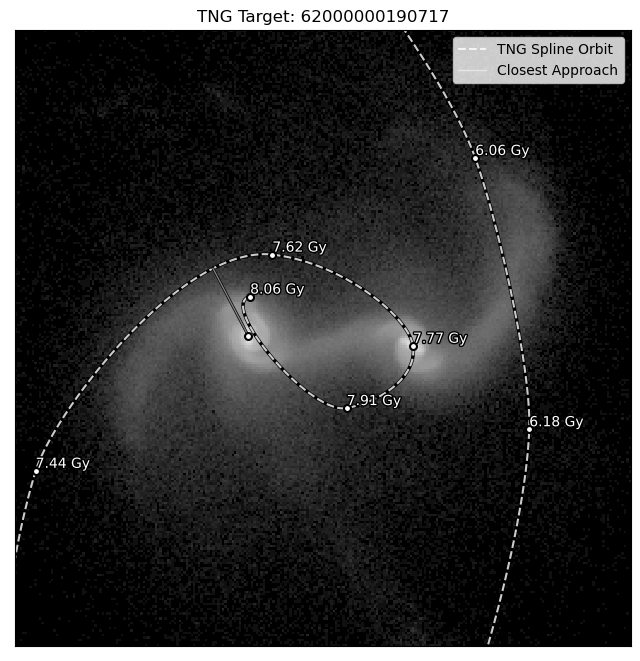

In [11]:
def plot_target( self,
                overwrite_hist = None,
                append_plots = None,
                append_scatter = None,
                append_annotations = None,
                plot_title = None,
                ext_ax = None,
                bins = 256,
                std_dev = 3,
                ):  
    
    self.logger.info("Plotting Target: %s", self.target_id)

    # Set plot title
    if ext_ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8,8))
    else:
        ax = ext_ax
    
    # Set plot title
    if plot_title is None:
        plot_title = f"TNG Target: {self.target_id}"
    ax.set_title( plot_title )
    
    # Set particles to 2D hist
    if overwrite_hist is None:
        hist_data = self.pts
    else:
        hist_data = overwrite_hist
    
    # Set plot data
    # Add target spline with formmating
    plot_data = [ ( self.spline['orbit'], {'color':'white', 'linewidth':1.5, 'label':'TNG Spline Orbit', 'linestyle': '--',  'label':'TNG Spline Orbit', 'alpha':.8} ) ]
    plot_data.append( ( self.moca['vector'], {'color':'white', 'linewidth':1, 'label':'Closest Approach', 'linestyle': '-', 'alpha':.5} ) ) # MOCA Vector
    if append_plots is not None:
        if isinstance(append_plots, list):
            plot_data.extend( append_plots )
            
        else:
            plot_data.append( append_plots )
        
    
    # Add snapshots with Gyr to plot data
    annotations = []
    annotations.append( ( [0,0], '') )
    for i, snap in enumerate( self.state_history['snap'] ):
        anno_loc = self.orbits['fixed_su'][i,0:2]
        anno_text = f"{self.state_history['time_gyr'][i]:.2f} Gy"
        annotations.append( (anno_loc, anno_text) )

    if append_annotations is not None:
        if isinstance(append_annotations, list):
            annotations.extend( append_annotations )
        else:
            annotations.append( append_annotations )    
    
    tf.xy_histogram(
        hist_data = hist_data,
        plot_data = plot_data, 
        annotations=annotations,
        title=plot_title, std_dev = std_dev, 
        ext_ax=ax, bins=bins,
        show_labels=False, 
    )
    
    # Append any additional plots
    
setattr( TNG_Target_Class, 'plot_target', plot_target )

if buildEnv:
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )
    t1._convert_tng_data_to_spam_units()
    t1._gen_target_spline_data( spline_type = 'hermite' )
    t1._gen_moment_of_closest_approach()
    t1.plot_target( )

___
# SPAM Simulation Wrapper

Since we're going to be running the TNG Target through the SPAM simulor for testing, let's add a wrapper

[2025-03-27 11:50:47,631 - INFO - 2049302881.run_spam_orbit]: Generating SPAM orbit for target: 62000000190717
[2025-03-27 11:50:47,632 - DEBUG - 2049302881.run_spam_orbit]: Using SPAM parameters: {}
[2025-03-27 11:50:47,633 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 11:50:47,634 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 11:50:51,975 - INFO - 2049302881.gen_spam_orbit_annotations]: Generating SPAM orbit annotations for target: 62000000190717
[2025-03-27 11:50:51,976 - DEBUG - 2049302881.gen_spam_orbit_annotations]: Using SPAM orbit: (721, 7)
[2025-03-27 11:50:51,979 - INFO - 2049302881.run_spam_orbit]: Generating SPAM orbit for target: 62000000190717
[2025-03-27 11:50:51,980 - DEBUG - 2049302881.run_spam_orbit]: Using SPAM parameters: {'m_halo': 6.4, 'lnl': 0.005, 'r_scale': 19.5}
[2025-03-27 11:50:51,981 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 11:50:51,982 - IN

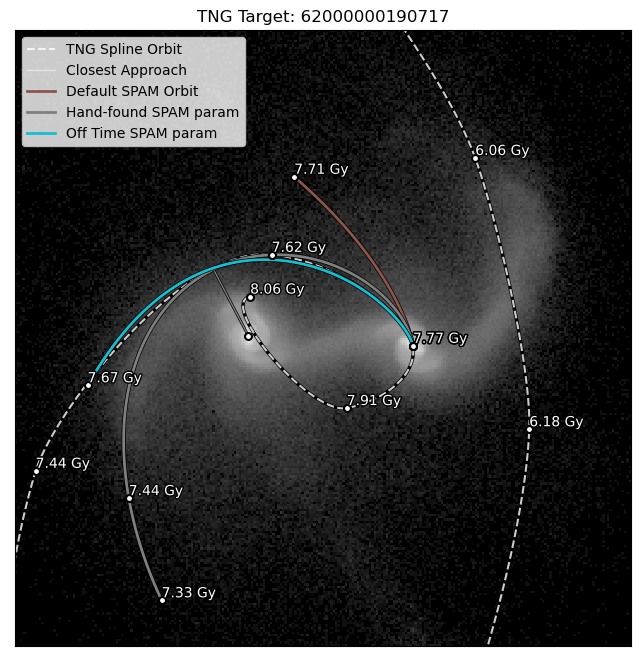

In [12]:
def run_spam_orbit( self, spam_param = {}, spam_ar = None ):
    """
    Use the target collision parameters to simulate a spam orbit for the secondary galaxy.
    
    Parameters:
    - spam_param: dict, optional parameters for the SPAM simulation parameters.
    
    Returns:
    - orbit: numpy array, the generated SPAM orbit for the secondary galaxy.
    """

    self.logger.info("Generating SPAM orbit for target: %s", self.target_id)
    self.logger.debug( "Using SPAM parameters: %s", str(spam_param) )

    # Use target spam_ar if none given
    if spam_ar is None:
        spam_ar = self.spam_ar

    # Generate Orbit
    orbit = sim.spam_orbit( spam_ar, spam_setup_params=spam_param, current_time=self.current_state['time_su'] )

    self.logger

    return orbit
setattr( TNG_Target_Class, 'run_spam_orbit', run_spam_orbit )

def gen_spam_orbit_annotations( self, spam_orbit ):

    # Get list of snapshots that fall within spam orbits time
    self.logger.info( "Generating SPAM orbit annotations for target: %s" % self.target_id )
    self.logger.debug( f"Using SPAM orbit: {spam_orbit.shape}" )

    snap_times = self.state_history['time_su']
    snap_times = snap_times[ (snap_times >= spam_orbit[0,6]) & (snap_times <= spam_orbit[-1,6]) ]
    
    annotations = []
    # Always add beginning of spam orbit
    loc = ( spam_orbit[0,0], spam_orbit[0,1] )   # locations
    time = self.convert_time_spam_to_tng( spam_orbit[0,-1] )  # text for annotation
    annotations.append( ( loc, f"{time:.2f} Gy" ) )

    # Add annotations for each snapshot time
    for i, snap_time in enumerate( snap_times ):

        snap_idx = np.argmin( np.abs( self.state_history['time_su'] - snap_time ) )  # Get index of closest snapshot
        if snap_idx == self.current_state['snap']: continue # Ignore if current snap
        spam_idx = np.argmin( np.abs( spam_orbit[:,-1] - snap_time ) )  # Get spam index closest to snapshot time
        loc = spam_orbit[ spam_idx, 0:2 ]   # locations
        text = f"{self.state_history.iloc[snap_idx]['time_gyr']:.2f} Gy"  # text for annotation
        annotations.append( (loc, text) )
    
    return annotations
setattr( TNG_Target_Class, 'gen_spam_orbit_annotations', gen_spam_orbit_annotations )

if buildEnv:
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.WARNING )
    t1._convert_tng_data_to_spam_units()
    t1._gen_target_spline_data( spline_type = 'hermite' )
    t1._gen_moment_of_closest_approach()
    t1._gen_spam_collision_parameters( radius_scale = 5.0, softening_scale = 0.1 )

    t1.set_log_level( logging.DEBUG )
    add_plots = []
    add_anno = []
 
    spam_orbit = t1.run_spam_orbit( spam_param = {}, spam_ar = t1.spam_ar )
    spam_anno = t1.gen_spam_orbit_annotations( spam_orbit )
    add_plots.append( ( spam_orbit, 'Default SPAM Orbit' ) )
    add_anno.extend( spam_anno )

    hand_orbit = t1.run_spam_orbit( spam_param = { 'm_halo': 6.4, 'lnl': 0.005, 'r_scale': 19.5 } )    
    hand_anno = t1.gen_spam_orbit_annotations( hand_orbit )
    add_plots.append( ( hand_orbit, 'Hand-found SPAM param' ) )
    add_anno.extend( hand_anno )

    off_orbit = t1.run_spam_orbit( spam_param = { 'm_halo': 12, 'lnl': 0.045, 'r_scale':10, } )    
    off_anno = t1.gen_spam_orbit_annotations( off_orbit )
    add_plots.append( ( off_orbit, 'Off Time SPAM param' ) )
    add_anno.extend( off_anno )

    t1.plot_target( append_plots = add_plots, append_annotations = add_anno )

[2025-03-27 11:51:02,190 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 11:51:02,192 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 11:51:05,497 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 11:51:05,498 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


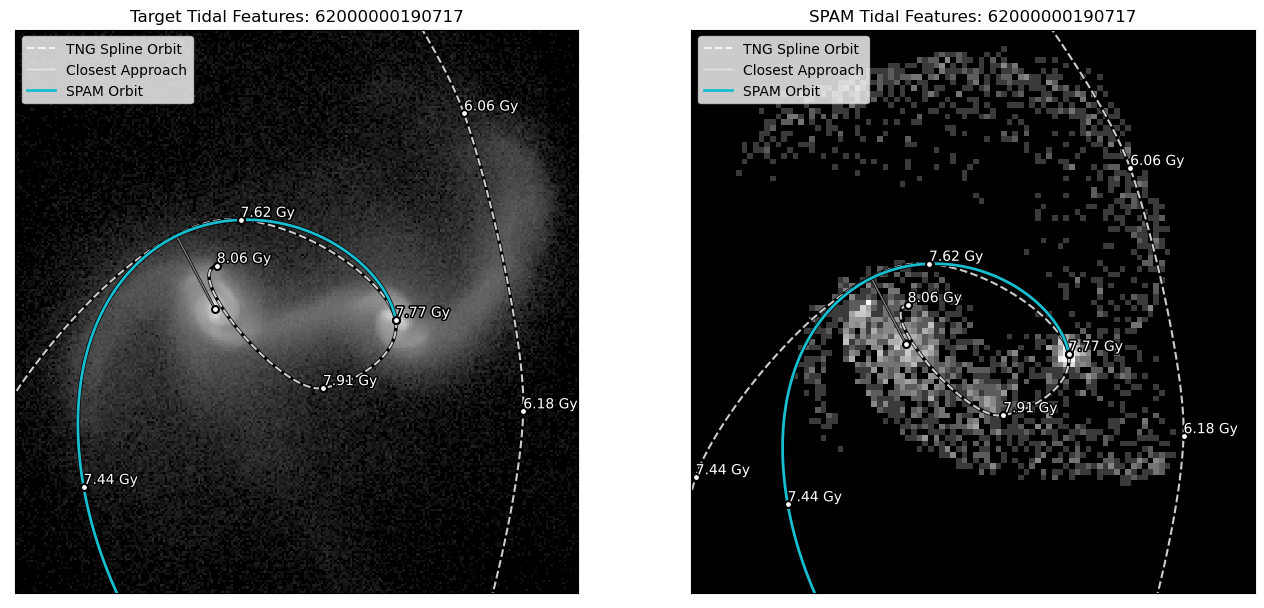

In [13]:
def run_spam_particles( self, spam_param = {}, spam_ar = None, n_pts = 1000, n_pts_2 = None, h1 = 0.1, h2 = None ):
    """
    Use the target collision parameters to simulate tidal features for the collion.
    
    Parameters:
    - spam_param: dict, optional parameters for the SPAM simulation parameters.
    
    Returns:
    - particles: numpy array, the simulated SPAM particles for the secondary galaxy.
    """

    self.logger.info("Generating SPAM particles for target: %s", self.target_id)
    self.logger.debug( "Using SPAM parameters: %s", str(spam_param) )

    # Use target spam_ar if none given
    if spam_ar is None:
        spam_ar = self.spam_ar
    
    # Use default n_pts and heat if none given
    if n_pts_2 is None:
        n_pts_2 = n_pts
    
    if h2 is None:
        h2 = h1

    # Generate Particles
    ipts, fpts = sim.basic_run( spam_ar, spam_setup_params=spam_param, npts1=n_pts, npts2=n_pts_2, heat1=h1, heat2=h2 )

    self.logger.debug( "Initial Particles: %s" % str(ipts.shape) )
    self.logger.debug( "Final Particles: %s" % str(fpts.shape) )

    return (ipts, fpts)
setattr( TNG_Target_Class, 'run_spam_particles', run_spam_particles )

from math import floor
if buildEnv:
    
    # New TNG Target Class
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.WARNING )
    t1._convert_tng_data_to_spam_units()
    t1._gen_target_spline_data( spline_type = 'hermite' )
    t1._gen_moment_of_closest_approach()
    t1._gen_spam_collision_parameters( radius_scale = 5.0, softening_scale = 0.1 )

    
    # Create orbit
    hand_found = { 'm_halo': 6.4, 'lnl': 0.005, 'r_scale': 19.5 }
    orbit = t1.run_spam_orbit( spam_param = hand_found )
    anno = t1.gen_spam_orbit_annotations( orbit )
    _, pts = t1.run_spam_particles( spam_param = hand_found, n_pts=1000, n_pts_2=2000 )

    fig, ax = plt.subplots( 1, 2, figsize=(16,8) )

    t1.plot_target(
        append_plots = ( orbit, 'SPAM Orbit' ),
        append_annotations = anno,
        ext_ax=ax[0], bins=256, std_dev=2.5,
        plot_title = f"Target Tidal Features: {t1.target_id}",
    )

    t1.plot_target(
        overwrite_hist = pts,
        append_plots = ( orbit, 'SPAM Orbit' ),
        append_annotations = anno,
        ext_ax=ax[1], bins=100, std_dev=2.5,
        plot_title = f"SPAM Tidal Features: {t1.target_id}",
    )

----
# Final TNG Target Class

[2025-03-27 12:09:56,594 - INFO - 338878711.__init__]: Initializing TNG Target Data
[2025-03-27 12:09:56,596 - INFO - 4176483620.extract_tng_target]: Extracting Target Data for: 62000000190717
[2025-03-27 12:09:57,320 - INFO - 4176483620.extract_tng_target]: Loaded Data: (26, 111)
[2025-03-27 12:09:57,341 - INFO - 4176483620.load_pts_data]: Loading TNG Particles Data: 62000000190717
[2025-03-27 12:09:58,243 - INFO - 4176483620.load_pts_data]: Particle Data: (1519823, 10)
[2025-03-27 12:09:58,245 - INFO - 3465369305._convert_tng_data_to_spam_units]: Converting TNG data to SPAM units for target: 62000000190717
[2025-03-27 12:09:58,246 - INFO - 4021226264._transform_tng_orbits]: Generating TNG Orbits: 62000000190717
[2025-03-27 12:09:58,961 - INFO - 1317353494._gen_splines_hermite]: Interpolating path with Hermite cubic splines...
[2025-03-27 12:09:58,970 - INFO - 3885842407._gen_moment_of_closest_approach]: Generating Most Recent Moment of Closest Approach (MOCA) Info...
[2025-03-27 12:0


Running SPAM simulation for Default...


[2025-03-27 12:10:02,697 - INFO - 917359465.run_spam_particles]: Generating SPAM particles for target: 62000000190717
[2025-03-27 12:10:02,698 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:10:02,700 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:10:11,201 - INFO - 2049302881.run_spam_orbit]: Generating SPAM orbit for target: 62000000190717
[2025-03-27 12:10:11,202 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:10:11,204 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:10:15,781 - INFO - 2049302881.gen_spam_orbit_annotations]: Generating SPAM orbit annotations for target: 62000000190717



Running SPAM simulation for Hand Found...


[2025-03-27 12:10:15,790 - INFO - 917359465.run_spam_particles]: Generating SPAM particles for target: 62000000190717
[2025-03-27 12:10:15,791 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:10:15,793 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:11:07,079 - INFO - 2049302881.run_spam_orbit]: Generating SPAM orbit for target: 62000000190717
[2025-03-27 12:11:07,083 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:11:07,085 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:11:11,840 - INFO - 2049302881.gen_spam_orbit_annotations]: Generating SPAM orbit annotations for target: 62000000190717



Running SPAM simulation for Off Time...


[2025-03-27 12:11:11,846 - INFO - 917359465.run_spam_particles]: Generating SPAM particles for target: 62000000190717
[2025-03-27 12:11:11,847 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:11:11,848 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:11:25,181 - INFO - 1617672699.plot_target]: Plotting Target: 62000000190717
[2025-03-27 12:11:25,535 - INFO - 1617672699.plot_target]: Plotting Target: 62000000190717
[2025-03-27 12:11:25,590 - INFO - 1617672699.plot_target]: Plotting Target: 62000000190717
[2025-03-27 12:11:25,648 - INFO - 1617672699.plot_target]: Plotting Target: 62000000190717


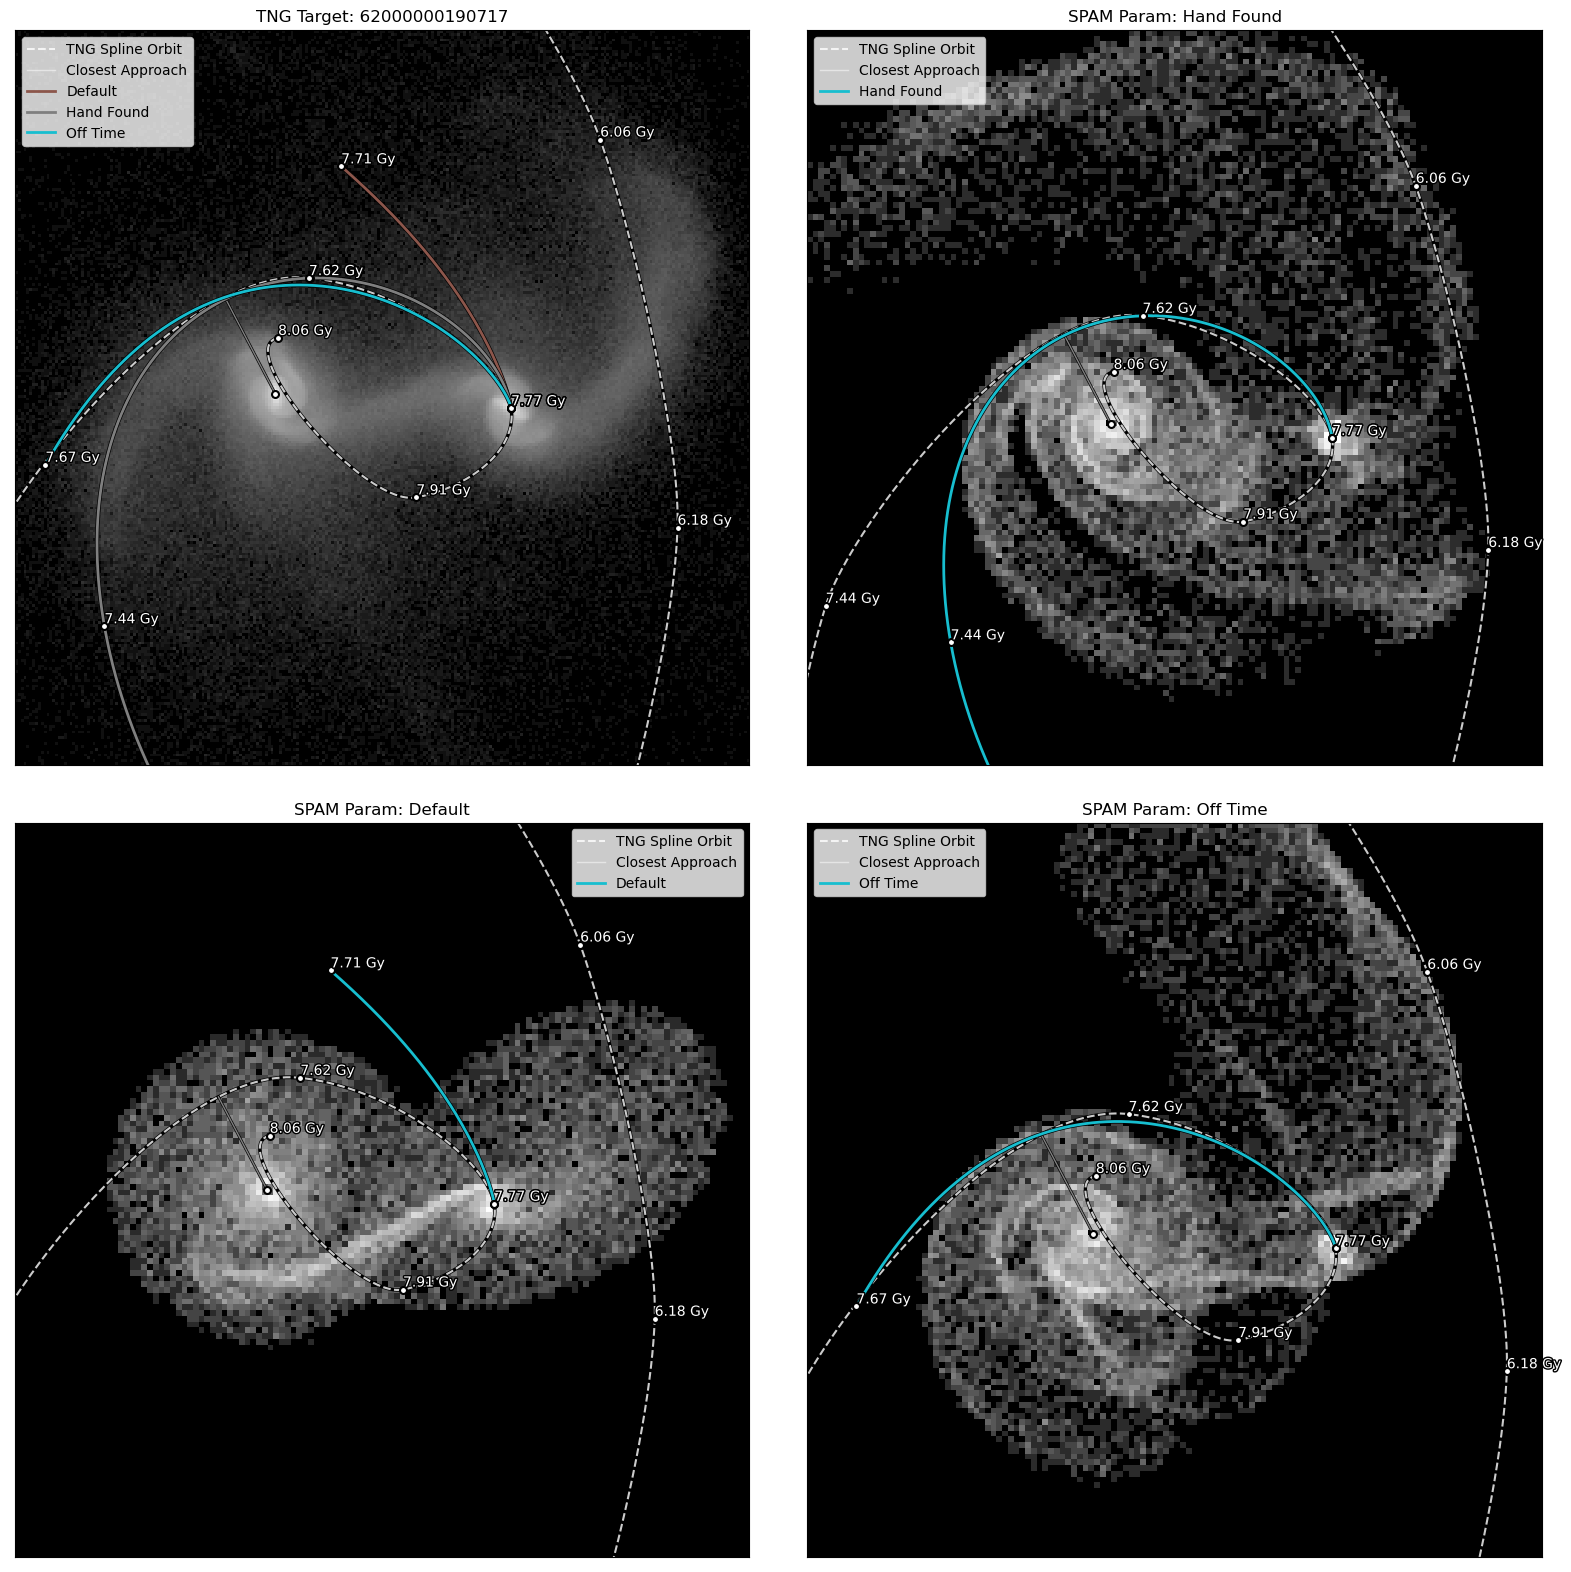

In [19]:


def __init__(self, target_id, 
                log_level = logging.INFO,
                all_targets_loc = "/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl",
                particle_dir = "/home/mbo2d/galStuff/data/tng-data/",
                spline_type = 'hermite',
                load_particles = True,
                ):

    self.logger = gu.configure_logger( logger_name='tng_target_class', log_level=log_level )
    self.logger.info("Initializing TNG Target Data")
    
    self.target_id = target_id
    self.load_particles = load_particles

    # Extract target data from a file
    self.current_idx, self.state_history = self.extract_tng_target( self.target_id, all_targets_loc )

    # Set approximate inbound index (will calculate exact later)
    self.inbound_idx = self.current_idx - 2

    # Load particles if requested
    if self.load_particles:
        self.pts = self.load_pts_data( self.target_id, particle_dir )
    
    # Convert TNG Data to SPAM units
    self._convert_tng_data_to_spam_units()

    # Generate the spline data for the target orbit
    self._gen_target_spline_data( spline_type = spline_type )

    # Generate misc data around the moment of closest approach (moca)
    self._gen_moment_of_closest_approach()

    # Finally, generate data needed to running tng collision parameters through SPAM simulation
    self._gen_spam_collision_parameters( radius_scale = 5.0, softening_scale = 0.1 )

    self.logger.info("Target Initalized")

setattr( TNG_Target_Class, '__init__', __init__ )

    
if buildEnv:

    # Final test
    t1 = TNG_Target_Class( p1, load_particles = True, log_level=logging.INFO )

    # Regen collision parameters with larger radius
    t1._gen_spam_collision_parameters( radius_scale = 7, softening_scale = 0.1 )

    spam_test = {
        'Default':{ 'param':{}},
        'Hand Found':{ 'param': { 'm_halo': 6.4, 'lnl': 0.005, 'r_scale': 19.5 } },
        'Off Time': {'param': { 'm_halo': 12, 'lnl': 0.045, 'r_scale':10, } }
    }

    # Loop and generate orbits and particles
    n1 = 10000
    n2 = 10000
    
    for key, value in spam_test.items():
        print(f"\nRunning SPAM simulation for {key}...")

        spam_test[key]['orbit'] = t1.run_spam_orbit( spam_param = value['param'] )
        spam_test[key]['anno'] = t1.gen_spam_orbit_annotations( spam_test[key]['orbit'] )
        _, spam_test[key]['pts'] = t1.run_spam_particles( spam_param = value['param'], n_pts=n1, n_pts_2=n2,)

    
    fig, ax = plt.subplots(2, 2, figsize=(16,16))
    fig.tight_layout()

    all_plot = [ ( spam_test[key]['orbit'], key) for key in spam_test ]
    all_anno = []
    [ all_anno.extend( spam_test[key]['anno'] ) for key in spam_test ]

    t1.plot_target( 
        append_plots= all_plot,
        append_annotations= all_anno,
        ext_ax=ax[0,0], bins=256, std_dev=2.5
    )
    
    for i, key in enumerate(spam_test):
        t1.plot_target(
            overwrite_hist = spam_test[key]['pts'],
            append_plots= ( spam_test[key]['orbit'], key),
            append_annotations = spam_test[key]['anno'] ,
            ext_ax=ax[(i+1)%2,floor((i+1)/2)], bins=128, std_dev=2.5,
            plot_title = f"SPAM Param: {key}",
        )

## Tidal Feature Analysis

From the below figure below, we can see that SPAM is indeed capable of recreating similar tidal features as the actual TNG Target.  However, you will note the default SPAM parameters from the Galaxy Zoo: Mergers effort, does not recreate them well.  It required some manually tweaking of the galactic model in SPAM to recreate the tidal features.  Note, I found two different parameter sets that are close to the original orbit.  One matches the orbit and IS close in time values as well.  However, the other named 'off time' was deliberately chose so the orbit position overlapped, but NOT the times of the orbit.  However, it still begins to recreate similar broad tidal features.  This proves one of our theories that the orbit path has a huge affect on tidal features, even if the collision parameters are very different. Directly comparing the hand-found and off-time tidal features, you are able to see small similarities. We hope these are enought to ultimately converge on the TNG targets.  

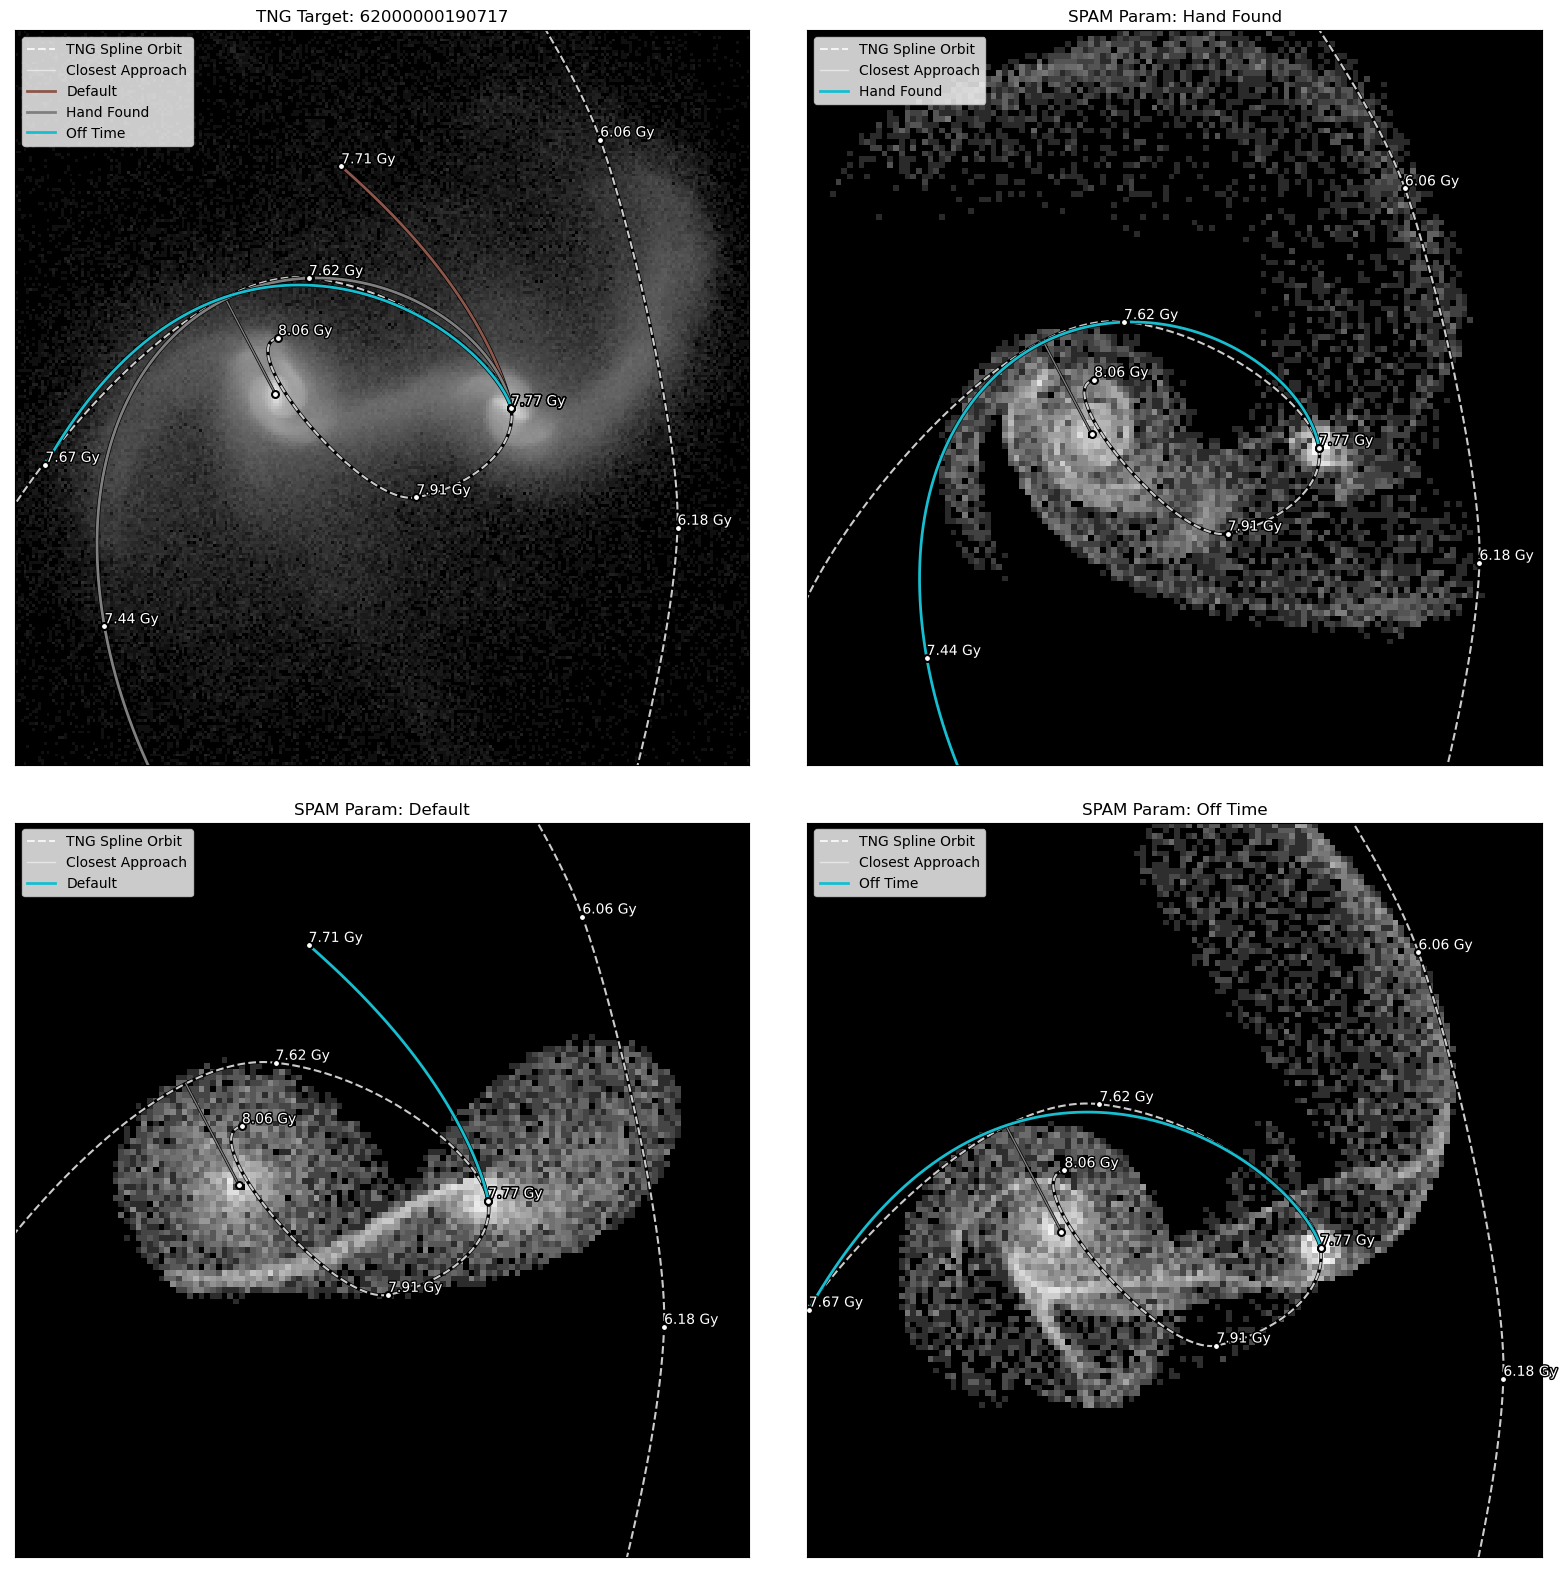

# Verify all targets

Let's run through all the targets and verify they're able to load points, and run spam simulations.

Target List: [47000000218473, 47000000255321, 50000000220008, 51000000255938, 52000000259327, 53000000234521, 54000000238368, 55000000244355, 55000000330164, 56000000247981, 56000000333739, 57000000252294, 58000000253571, 59000000181443, 60000000181501, 61000000186579, 62000000190717, 63000000192216, 64000000153811, 73000000145217, 73000000314755, 74000000145152, 74000000347159, 75000000121160, 75000000145473, 75000000317209, 75000000347840, 78000000398327, 81000000440813, 87000000451863]


[2025-03-27 12:12:24,324 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:12:24,326 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:12:27,972 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


Loaded Target: 47000000218473 - 47 - (1117453, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:12:27,973 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:12:39,371 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:12:39,373 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:12:42,702 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:12:42,705 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:11,884 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:13:11,888 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:15,691 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


	 Running SPAM simulation for Off Time...


[2025-03-27 12:13:15,694 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


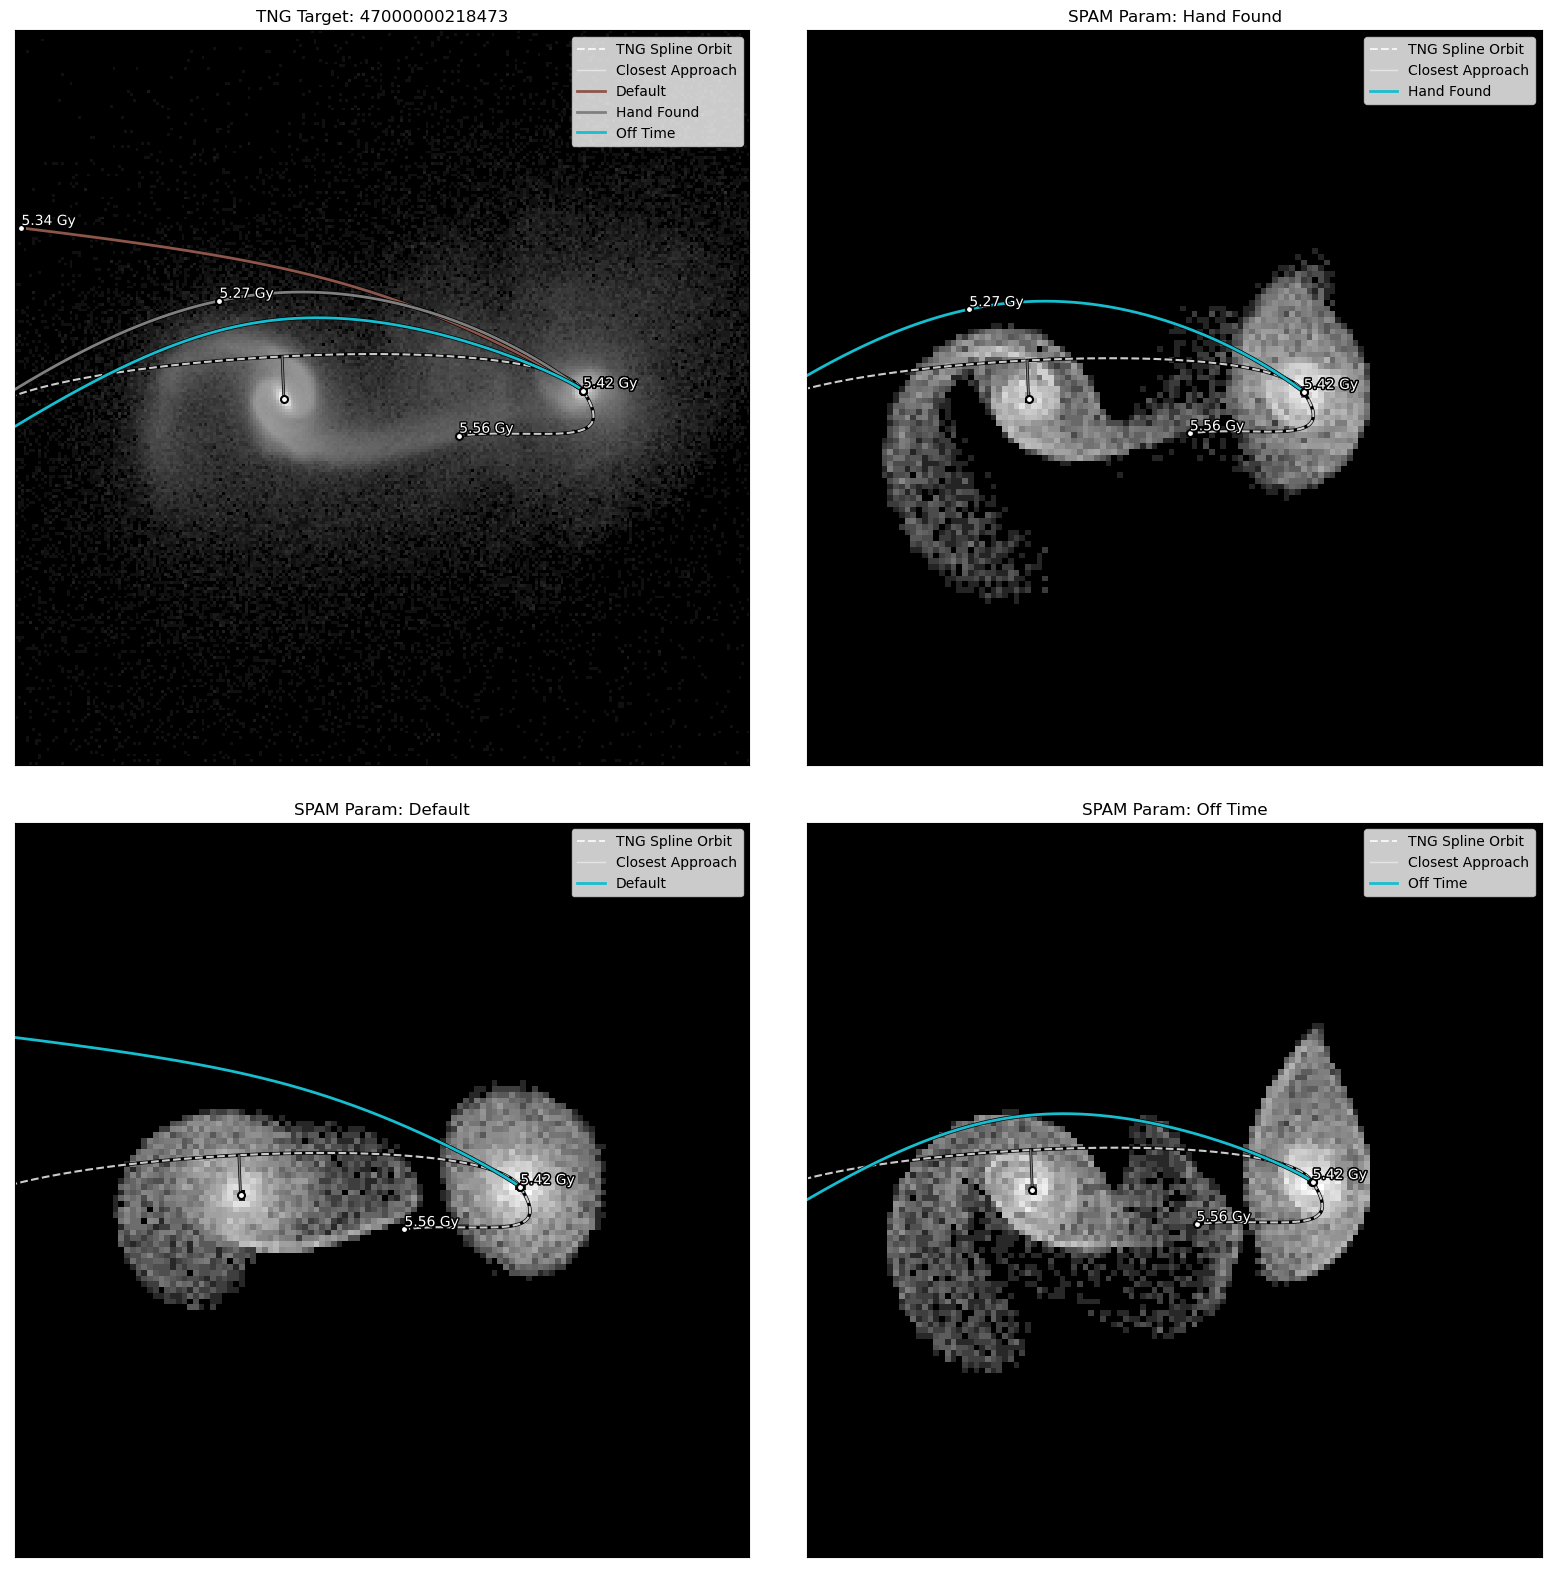

[2025-03-27 12:13:30,716 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:13:30,718 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:34,530 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


Loaded Target: 47000000255321 - 47 - (766323, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:13:34,533 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:41,020 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:13:41,022 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:44,954 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:13:44,959 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:55,662 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:13:55,666 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:13:58,767 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


	 Running SPAM simulation for Off Time...


[2025-03-27 12:13:58,769 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


<Figure size 640x480 with 0 Axes>

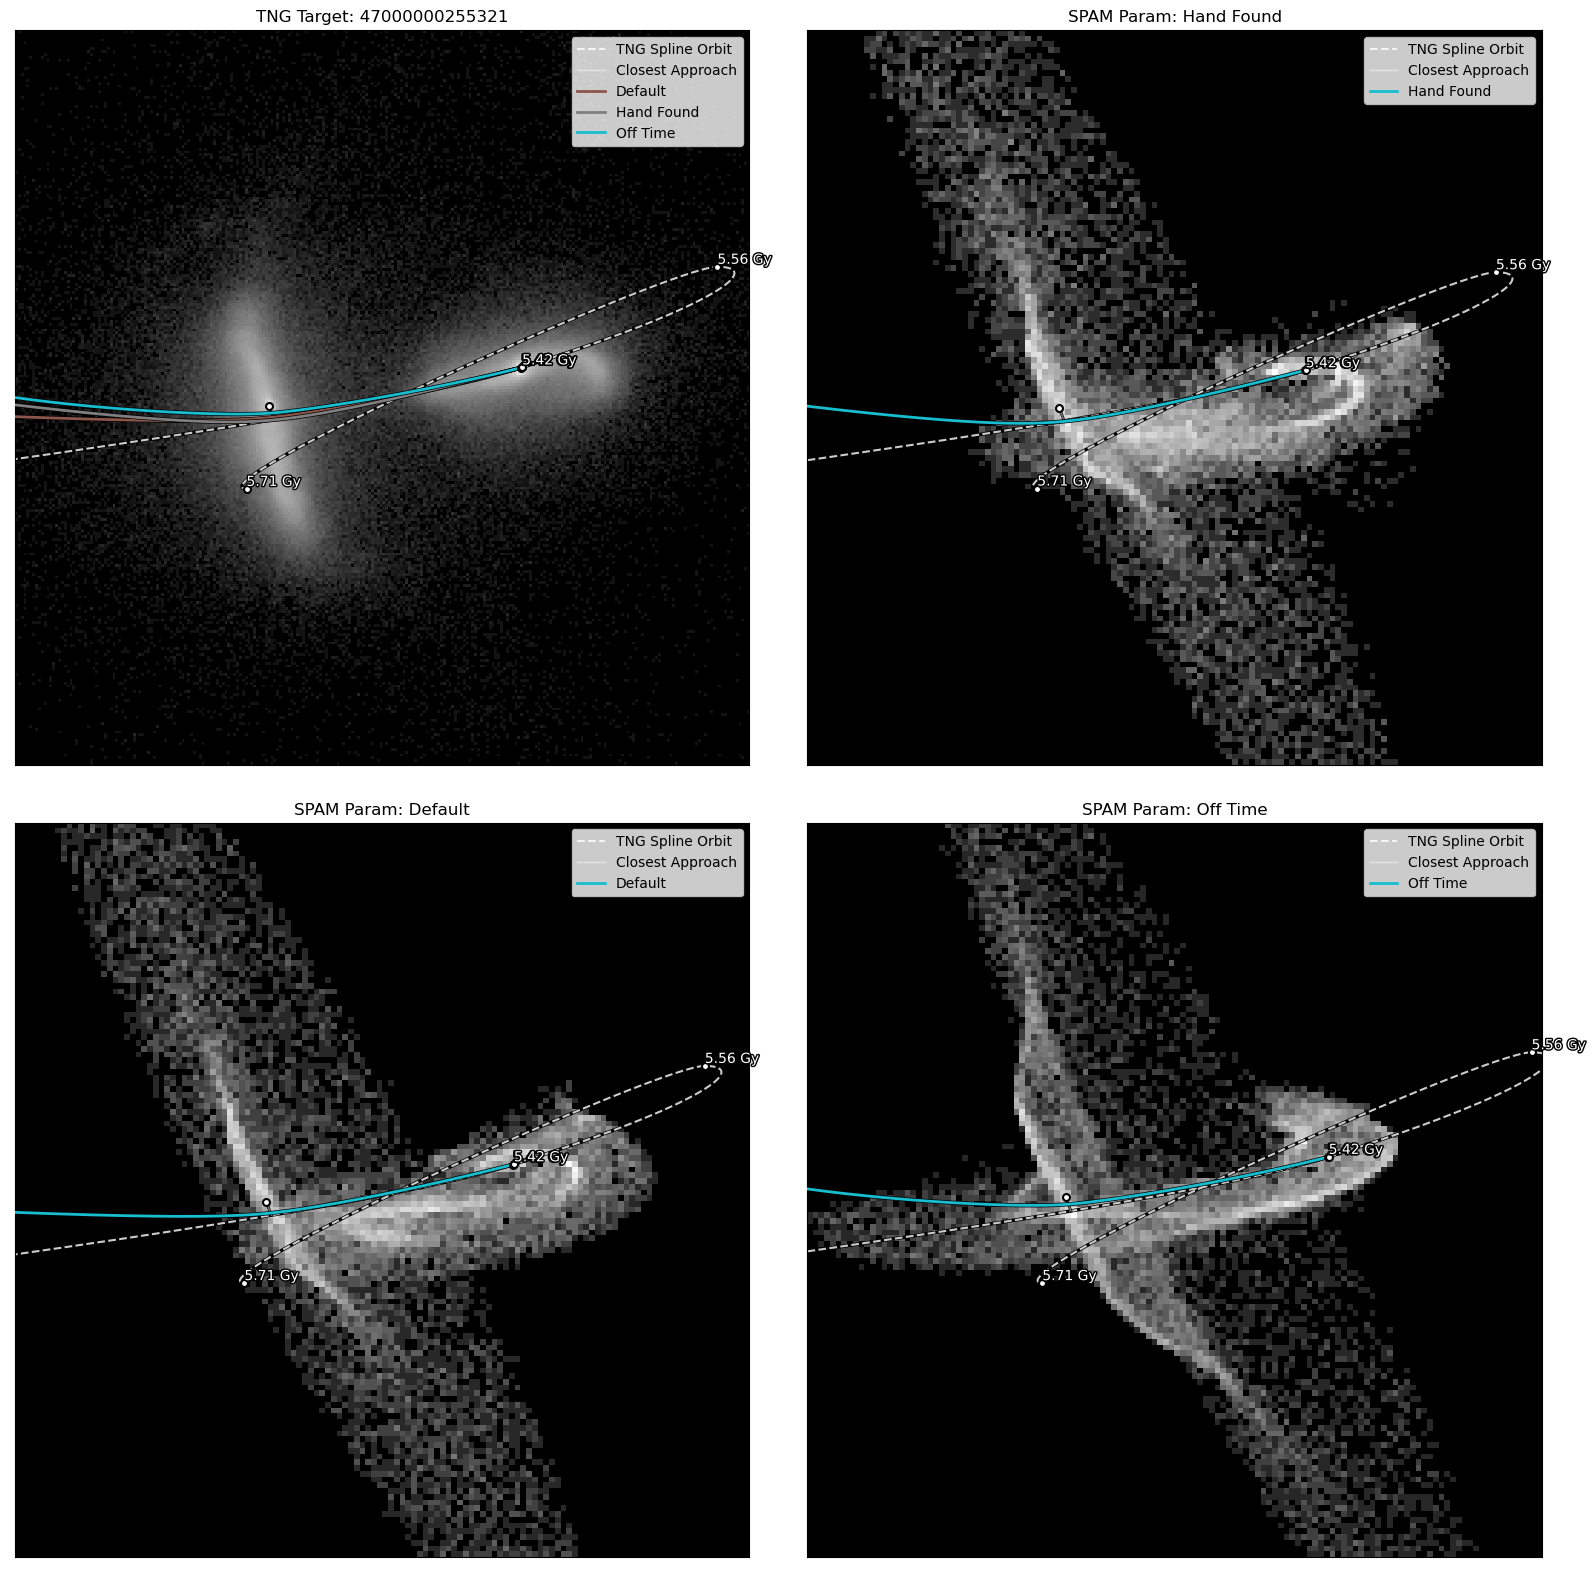

Failed to load target: 50000000220008 - index -1 is out of bounds for axis 0 with size 0
Failed to load target: 51000000255938 - index -1 is out of bounds for axis 0 with size 0


[2025-03-27 12:14:11,462 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:14:11,464 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


Loaded Target: 52000000259327 - 52 - (1163453, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:14:16,260 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:14:16,261 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:15:31,463 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:15:31,466 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:15:35,500 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:15:35,501 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:16:49,651 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:16:49,654 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Off Time...


[2025-03-27 12:16:54,159 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:16:54,160 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


<Figure size 640x480 with 0 Axes>

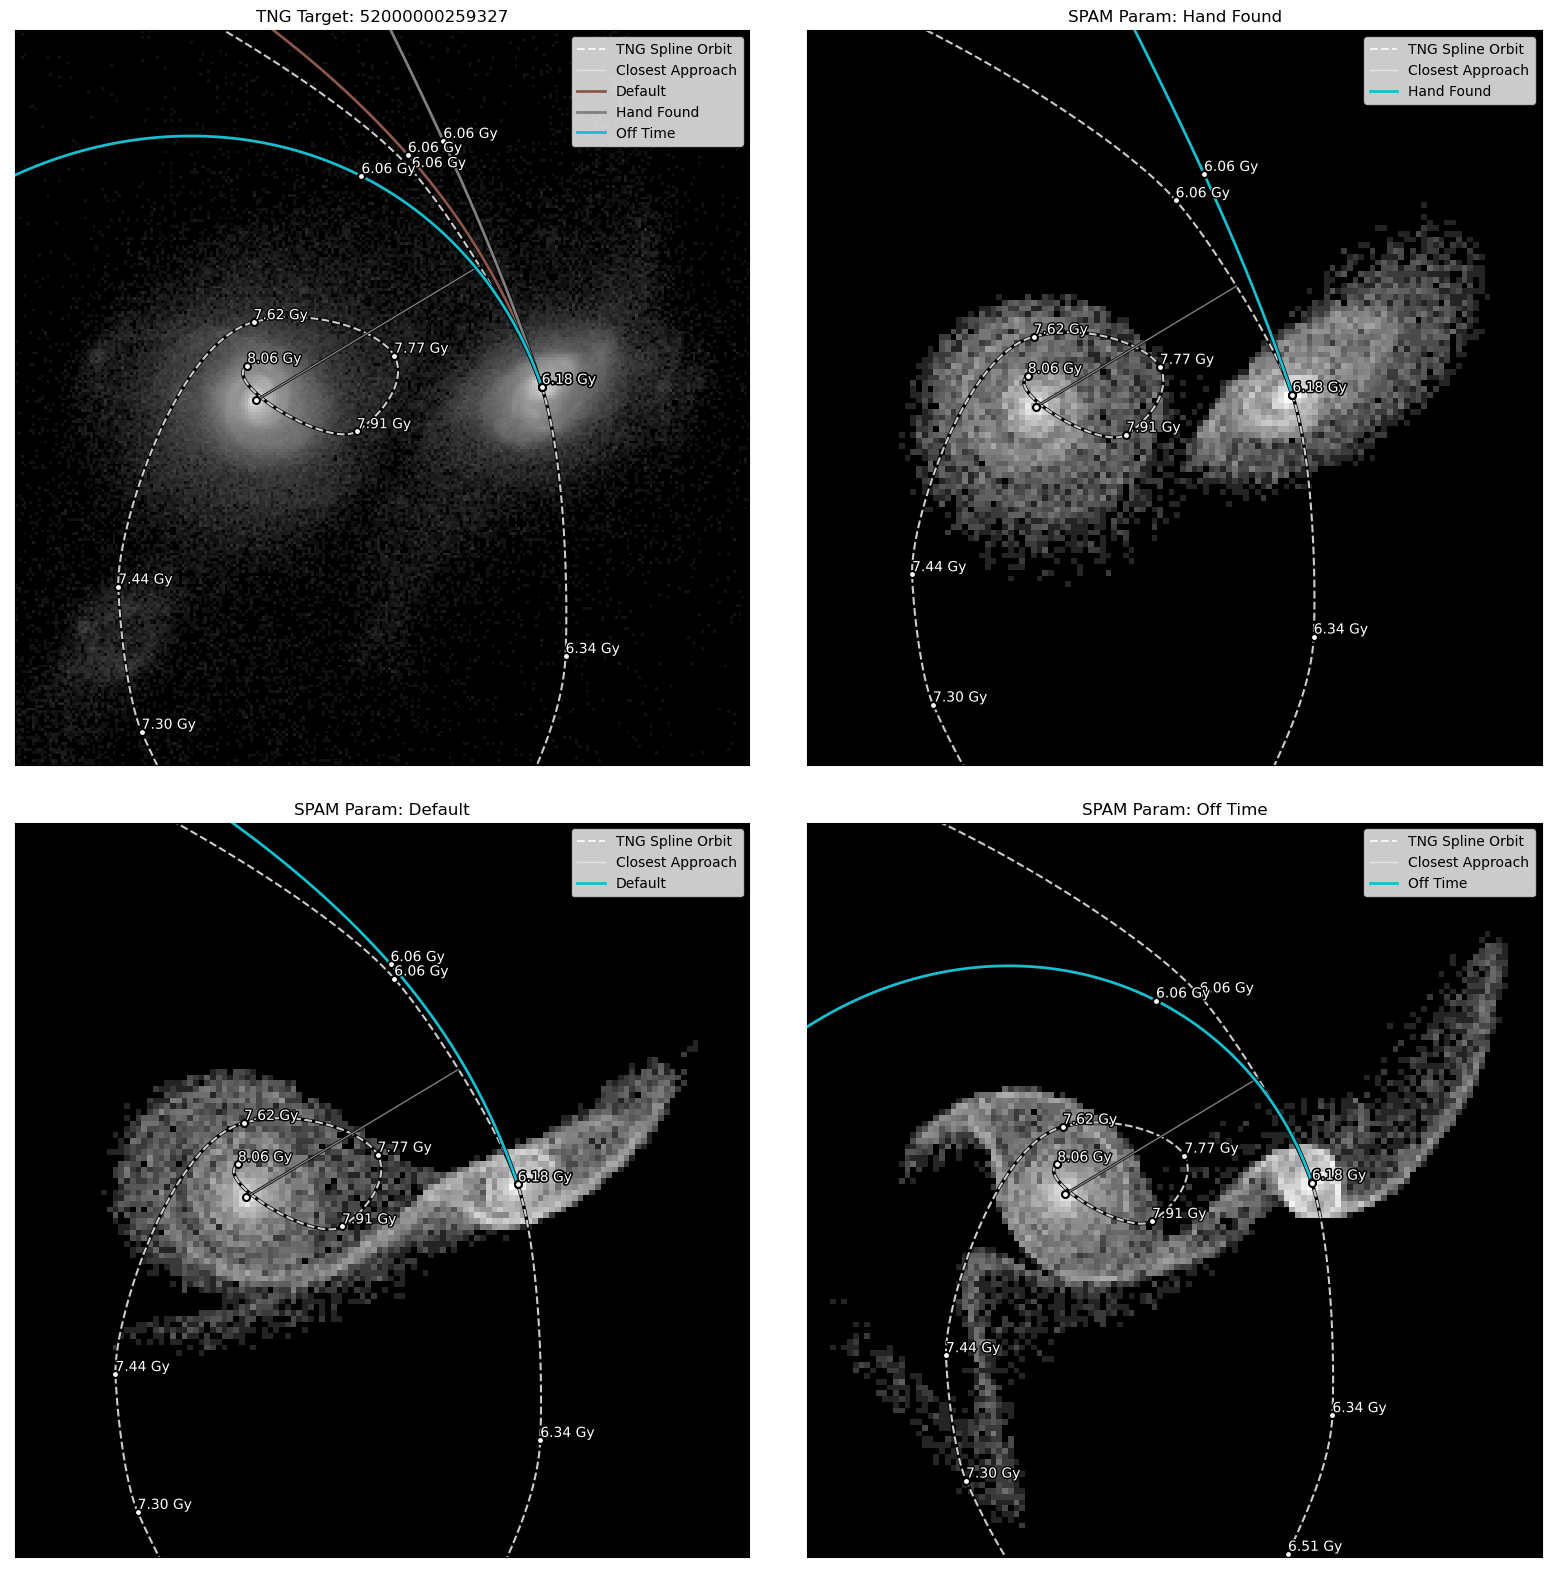

[2025-03-27 12:18:12,393 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:18:12,394 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


Loaded Target: 53000000234521 - 53 - (1245587, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:18:17,746 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:18:17,747 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:20:07,955 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:20:07,959 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:20:11,276 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:20:11,278 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:21:02,638 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:21:02,640 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Off Time...


[2025-03-27 12:21:06,524 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:21:06,526 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


<Figure size 640x480 with 0 Axes>

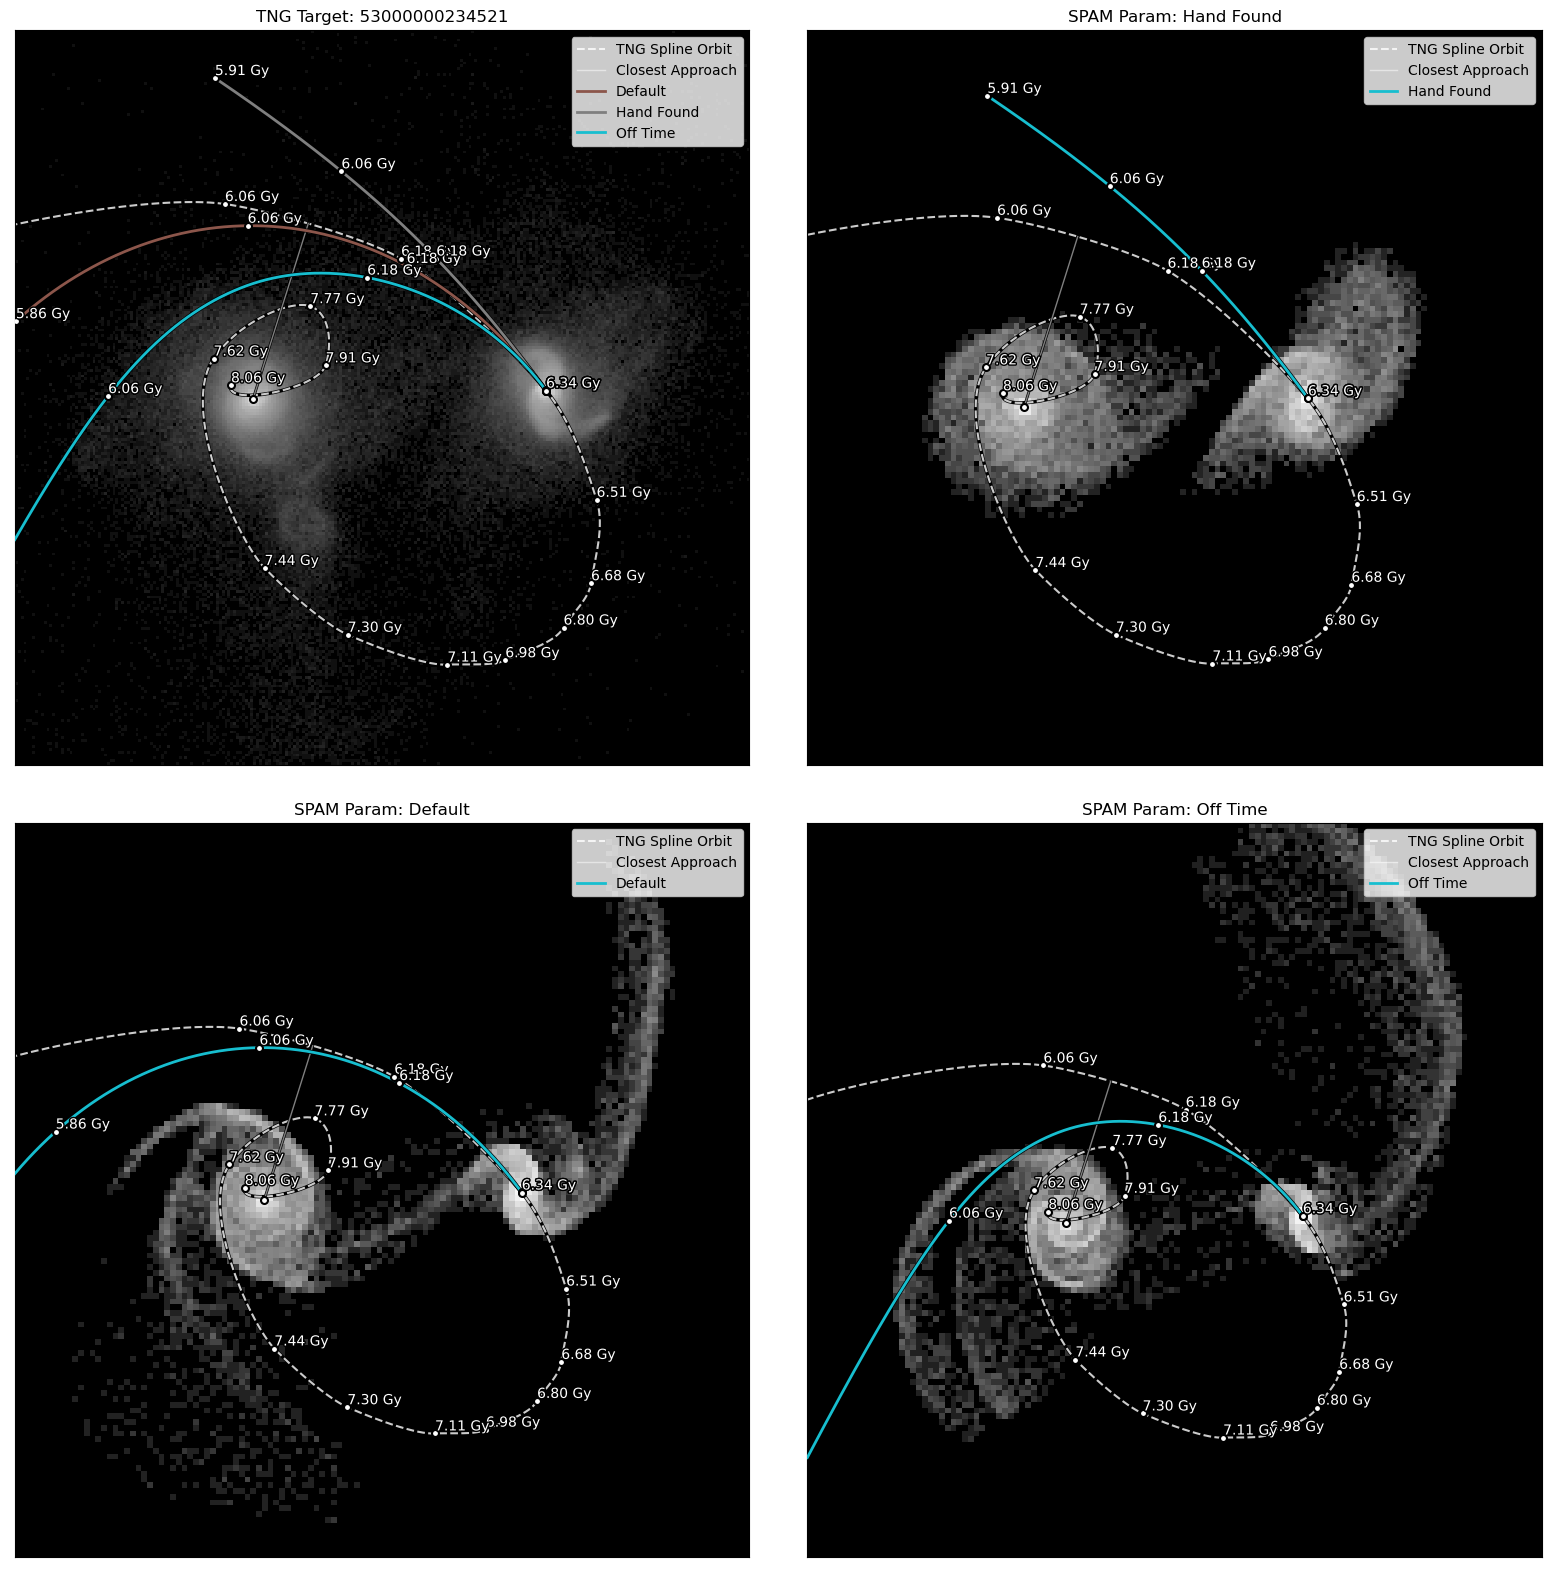

[2025-03-27 12:22:24,050 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:22:24,052 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


Loaded Target: 54000000238368 - 54 - (1301721, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:22:27,939 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:22:27,941 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:23:20,807 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:23:20,810 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:23:25,294 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:23:25,295 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:25:10,805 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:25:10,809 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:25:14,875 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


	 Running SPAM simulation for Off Time...


[2025-03-27 12:25:14,877 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


<Figure size 640x480 with 0 Axes>

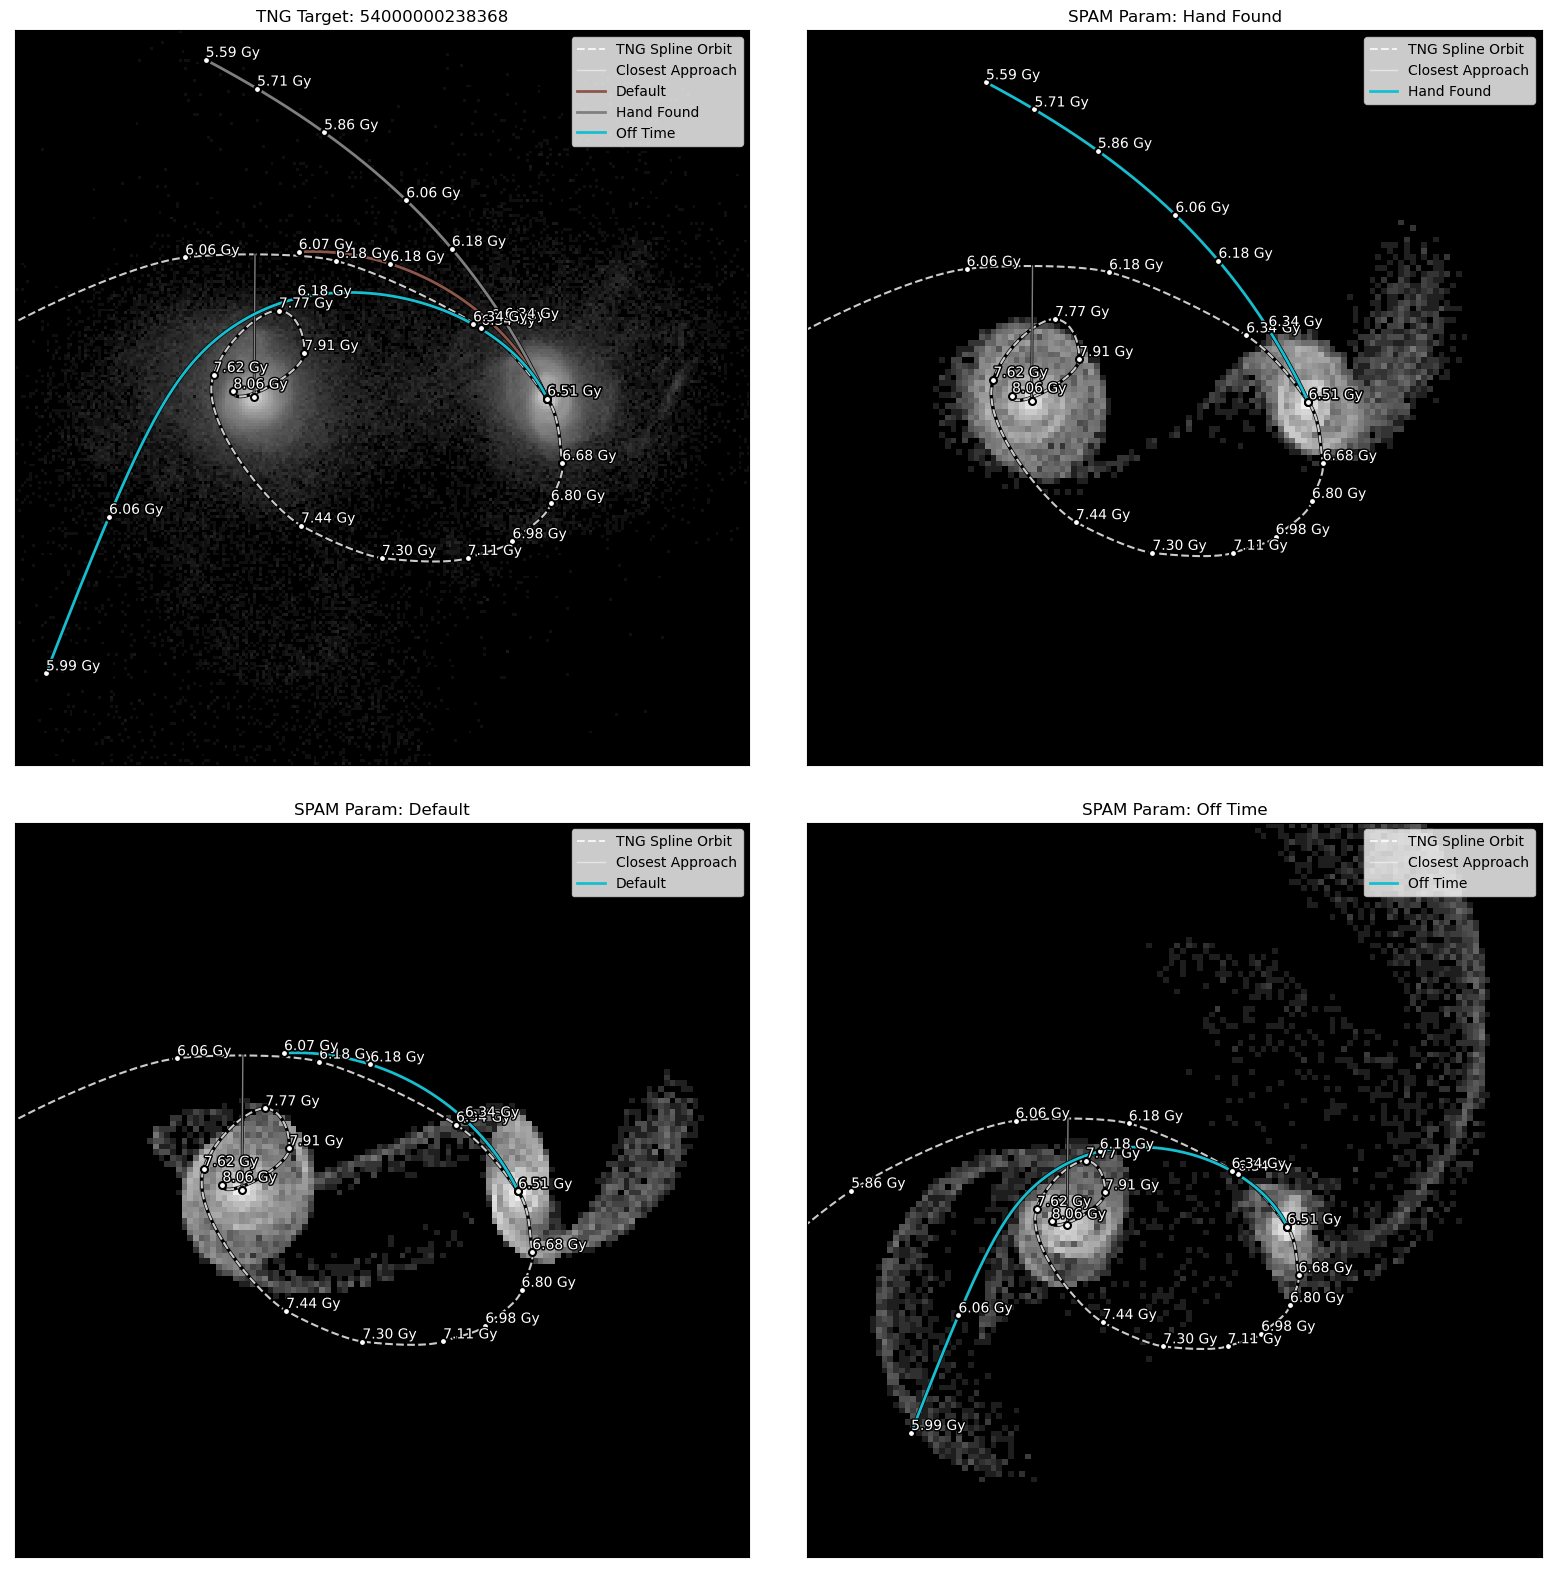

[2025-03-27 12:26:19,685 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:26:19,686 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


Loaded Target: 55000000244355 - 55 - (1340833, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:26:24,317 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:26:24,318 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:28:14,178 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:28:14,182 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:28:19,232 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:28:19,234 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:29:53,180 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:29:53,183 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Off Time...


[2025-03-27 12:29:57,863 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:29:57,864 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


<Figure size 640x480 with 0 Axes>

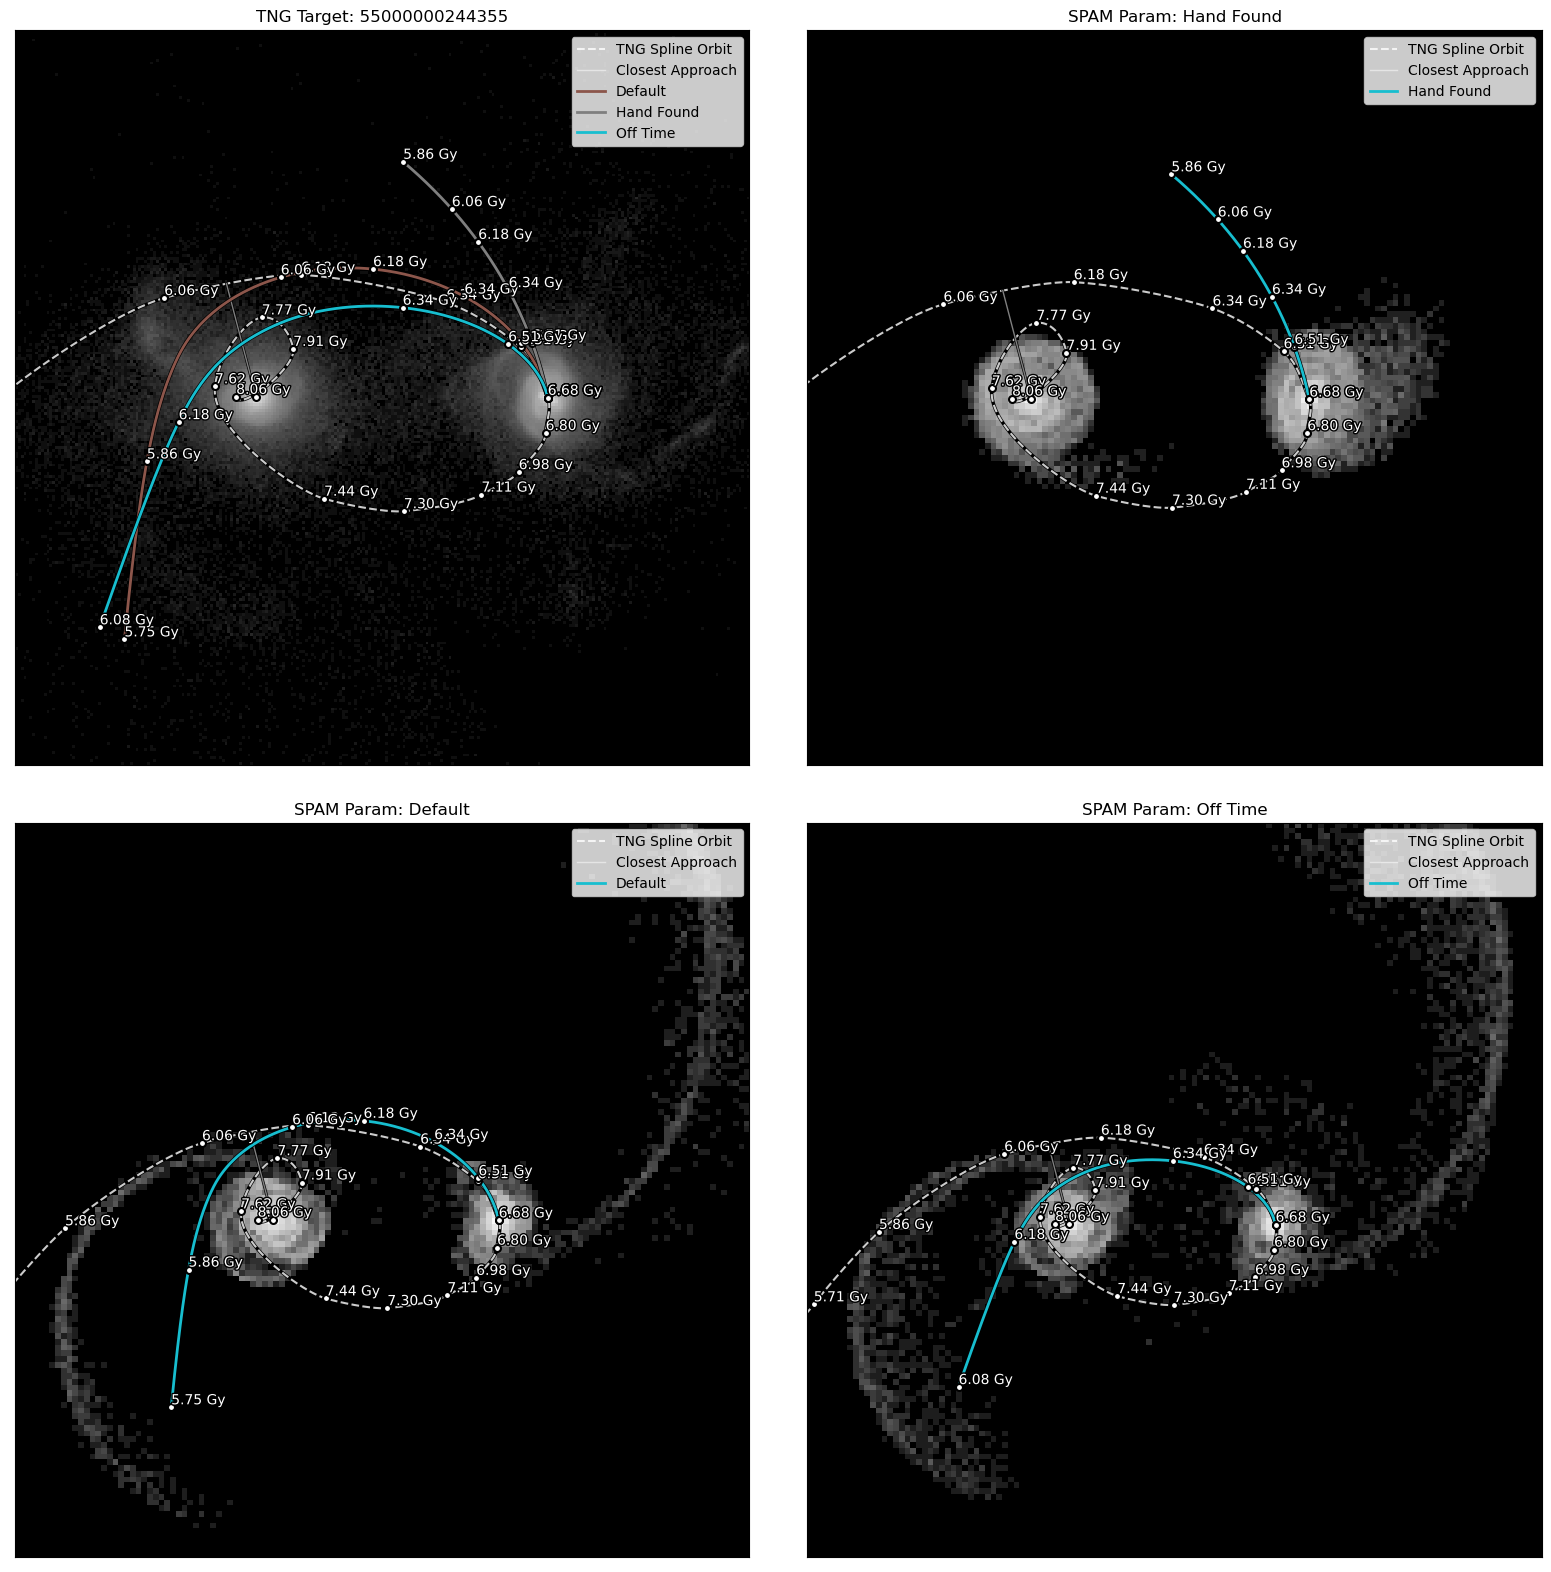

[2025-03-27 12:31:09,272 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:31:09,274 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:31:13,511 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run


Loaded Target: 55000000330164 - 55 - (714624, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:31:13,516 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:31:29,720 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:31:29,723 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Hand Found...


[2025-03-27 12:31:33,114 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:31:33,116 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 
[2025-03-27 12:32:12,618 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:32:12,621 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Running SPAM simulation for Off Time...


[2025-03-27 12:32:16,446 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:32:16,447 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


	 Plotting Target + SPAM data...


<Figure size 640x480 with 0 Axes>

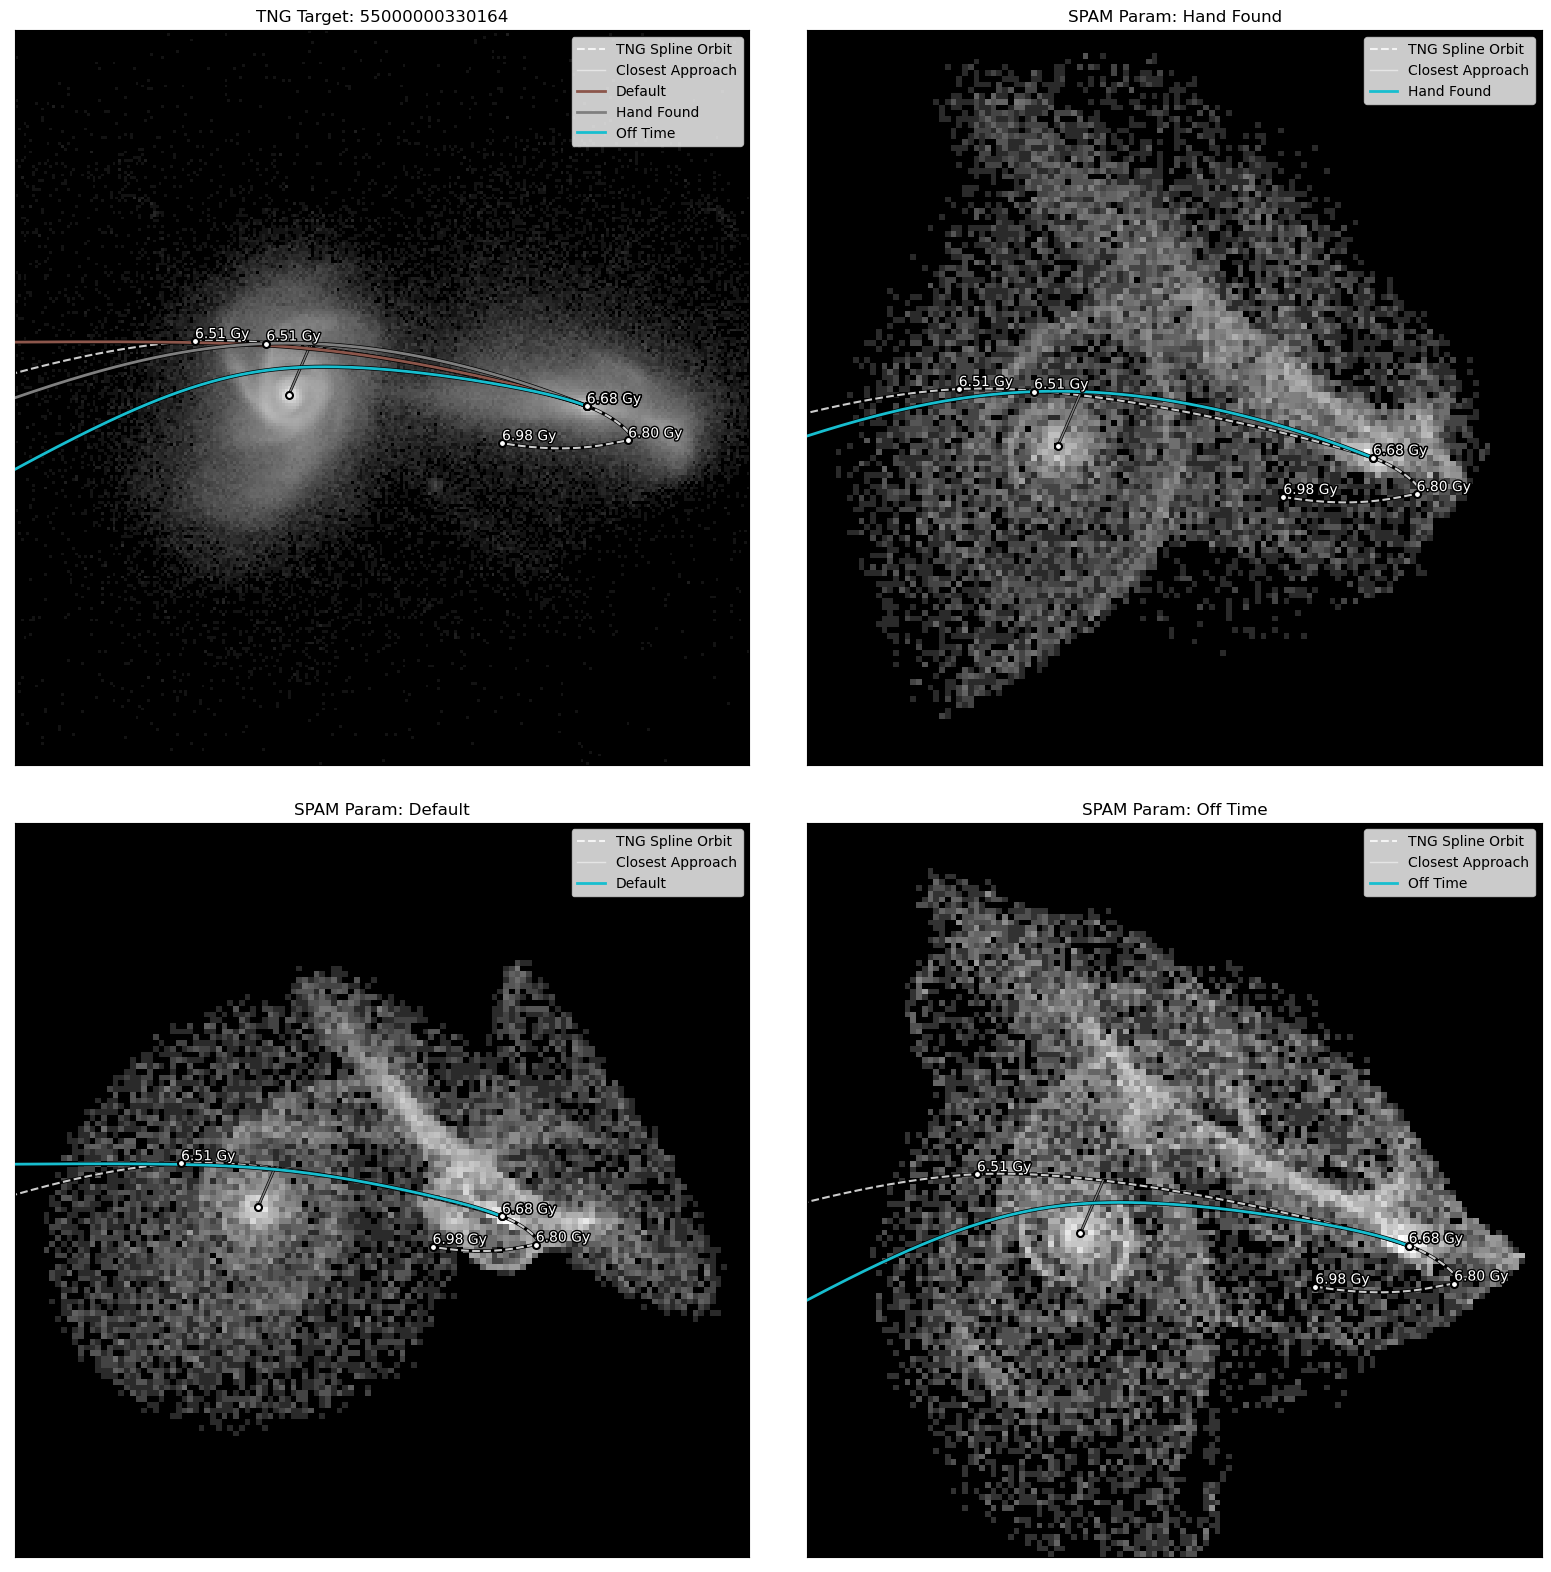

[2025-03-27 12:32:36,438 - INFO - new_simulator.spam_orbit]: Running SPAM Simulation - Orbit Run
[2025-03-27 12:32:36,439 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


Loaded Target: 56000000247981 - 56 - (1364422, 10)
	 Running SPAM simulation for Default...


[2025-03-27 12:32:40,415 - INFO - new_simulator.basic_run]: Running SPAM Simulation - Basic Run
[2025-03-27 12:32:40,416 - INFO - new_simulator.set_spam_parameters]: Setting SPAM Parameters: 


In [ ]:
if buildEnv:
    
    spam_test = {
        'Default':{ 'param':{}},
        'Hand Found':{ 'param': { 'm_halo': 6.4, 'lnl': 0.005, 'r_scale': 19.5 } },
        'Off Time': {'param': { 'm_halo': 12, 'lnl': 0.045, 'r_scale':10, } }
    }
    
    if True:
        # ALL TARGET TEST (SUCCESS)
        target_list = os.listdir('/home/mbo2d/galStuff/data/tng-data/')
        target_list = [ int(x.split('_')[1].split('.')[0]) for x in target_list if 'pts' in x ]
        target_list.sort()

        print( f"Target List: {target_list}")
        n = 1000

        # Loop through targets
        for i, pid in enumerate(target_list):
            try:
                # Load target
                t = TNG_Target_Class( pid, load_particles = True, log_level=logging.WARNING )

                # Regen collision parameters with larger radius
                t._gen_spam_collision_parameters( radius_scale = 7, softening_scale = 0.1 )

                # Regen collision parametesr
                print( f"Loaded Target: {pid} - {t.current_state['snap']} - {t.pts.shape}")

                target_data = spam_test.copy()

                # generate spam data
                for key, value in target_data.items():
                    print(f"\t Running SPAM simulation for {key}...")

                    target_data[key]['orbit'] = t.run_spam_orbit( spam_param = value['param'] )
                    target_data[key]['anno'] = t.gen_spam_orbit_annotations( target_data[key]['orbit'] )
                    _, target_data[key]['pts'] = t.run_spam_particles( spam_param = value['param'], n_pts=n1, n_pts_2=n2,)

                # Generate plots
                print(f"\t Plotting Target + SPAM data...")

                fig, ax = plt.subplots(2, 2, figsize=(16,16))
                fig.tight_layout()

                # Collect data for plotting
                all_plot = [ ( target_data[key]['orbit'], key) for key in target_data ]
                all_anno = []
                [ all_anno.extend( target_data[key]['anno'] ) for key in target_data ]

                # plots TNG target
                t.plot_target( 
                    append_plots= all_plot,
                    append_annotations= all_anno,
                    ext_ax=ax[0,0], bins=256, std_dev=2.5
                )
                
                # Plot SPAM simulations
                for j, key in enumerate(target_data):
                    t.plot_target(
                        overwrite_hist = target_data[key]['pts'],
                        append_plots= ( target_data[key]['orbit'], key),
                        append_annotations = target_data[key]['anno'] ,
                        ext_ax=ax[(j+1)%2,floor((j+1)/2)], bins=128, std_dev=2.5,
                        plot_title = f"SPAM Param: {key}",
                    )

            except Exception as e:
                print( f"Failed to load target: {pid} - {e}")
                continue

            plt.show()
            plt.clf()
            # if i >= 2: break
        print( "All targets loaded...")
    


---
---
# TNG to SPAM Conversion Analysis

Looking at the TNG orbit and SPAM orbit from TNG parameters, we can see the orbits have roughly the same shape, but do not appear to overlap well.   Target 2 does better, but it's concerning how much they do not overlap.  

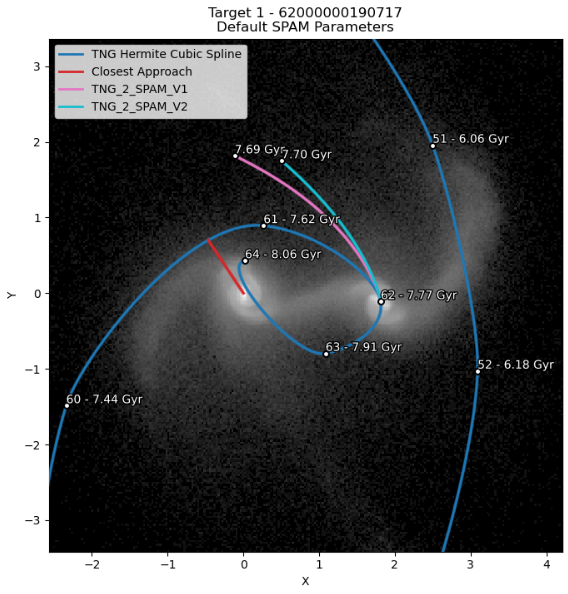
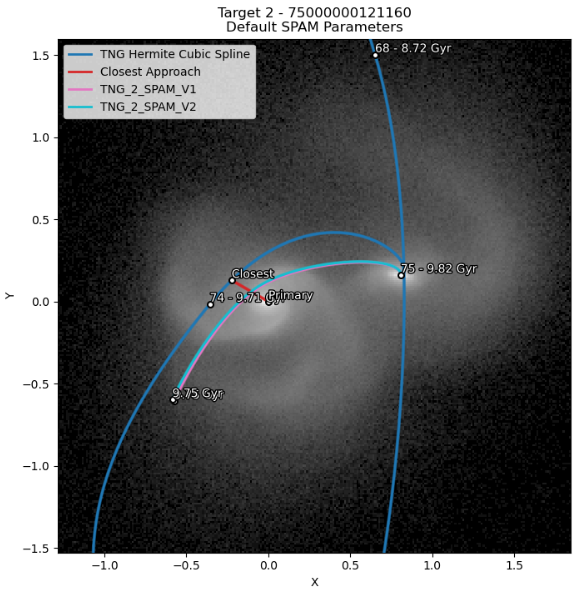


Let's see how well the tidal features match up.


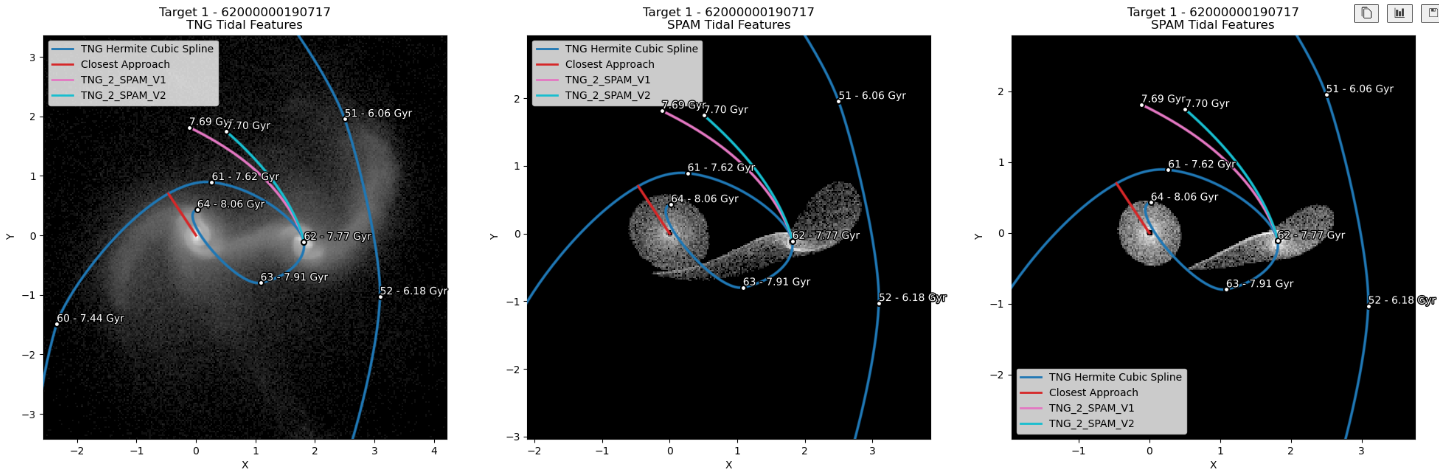

## Comparing v1 and v2
Looking at the orbits and tidal features, we can see that the version 1 and 2 functions of converting TNG target parameters into SPAM parameters do have a slight difference.  (See functions above for more details.)  Because I believe version 2 is more accurate, I will be using that for the actual TNG to SPAM conversion. 

## Comparing TNG to SPAM
Looking at the tidal features of both, we can see that the secondary galaxy is starting to form features.  But not the first.  This could be because the radius isn't long enough however.   Let's try increasing the radius and see if that helps.

---
---

---
---


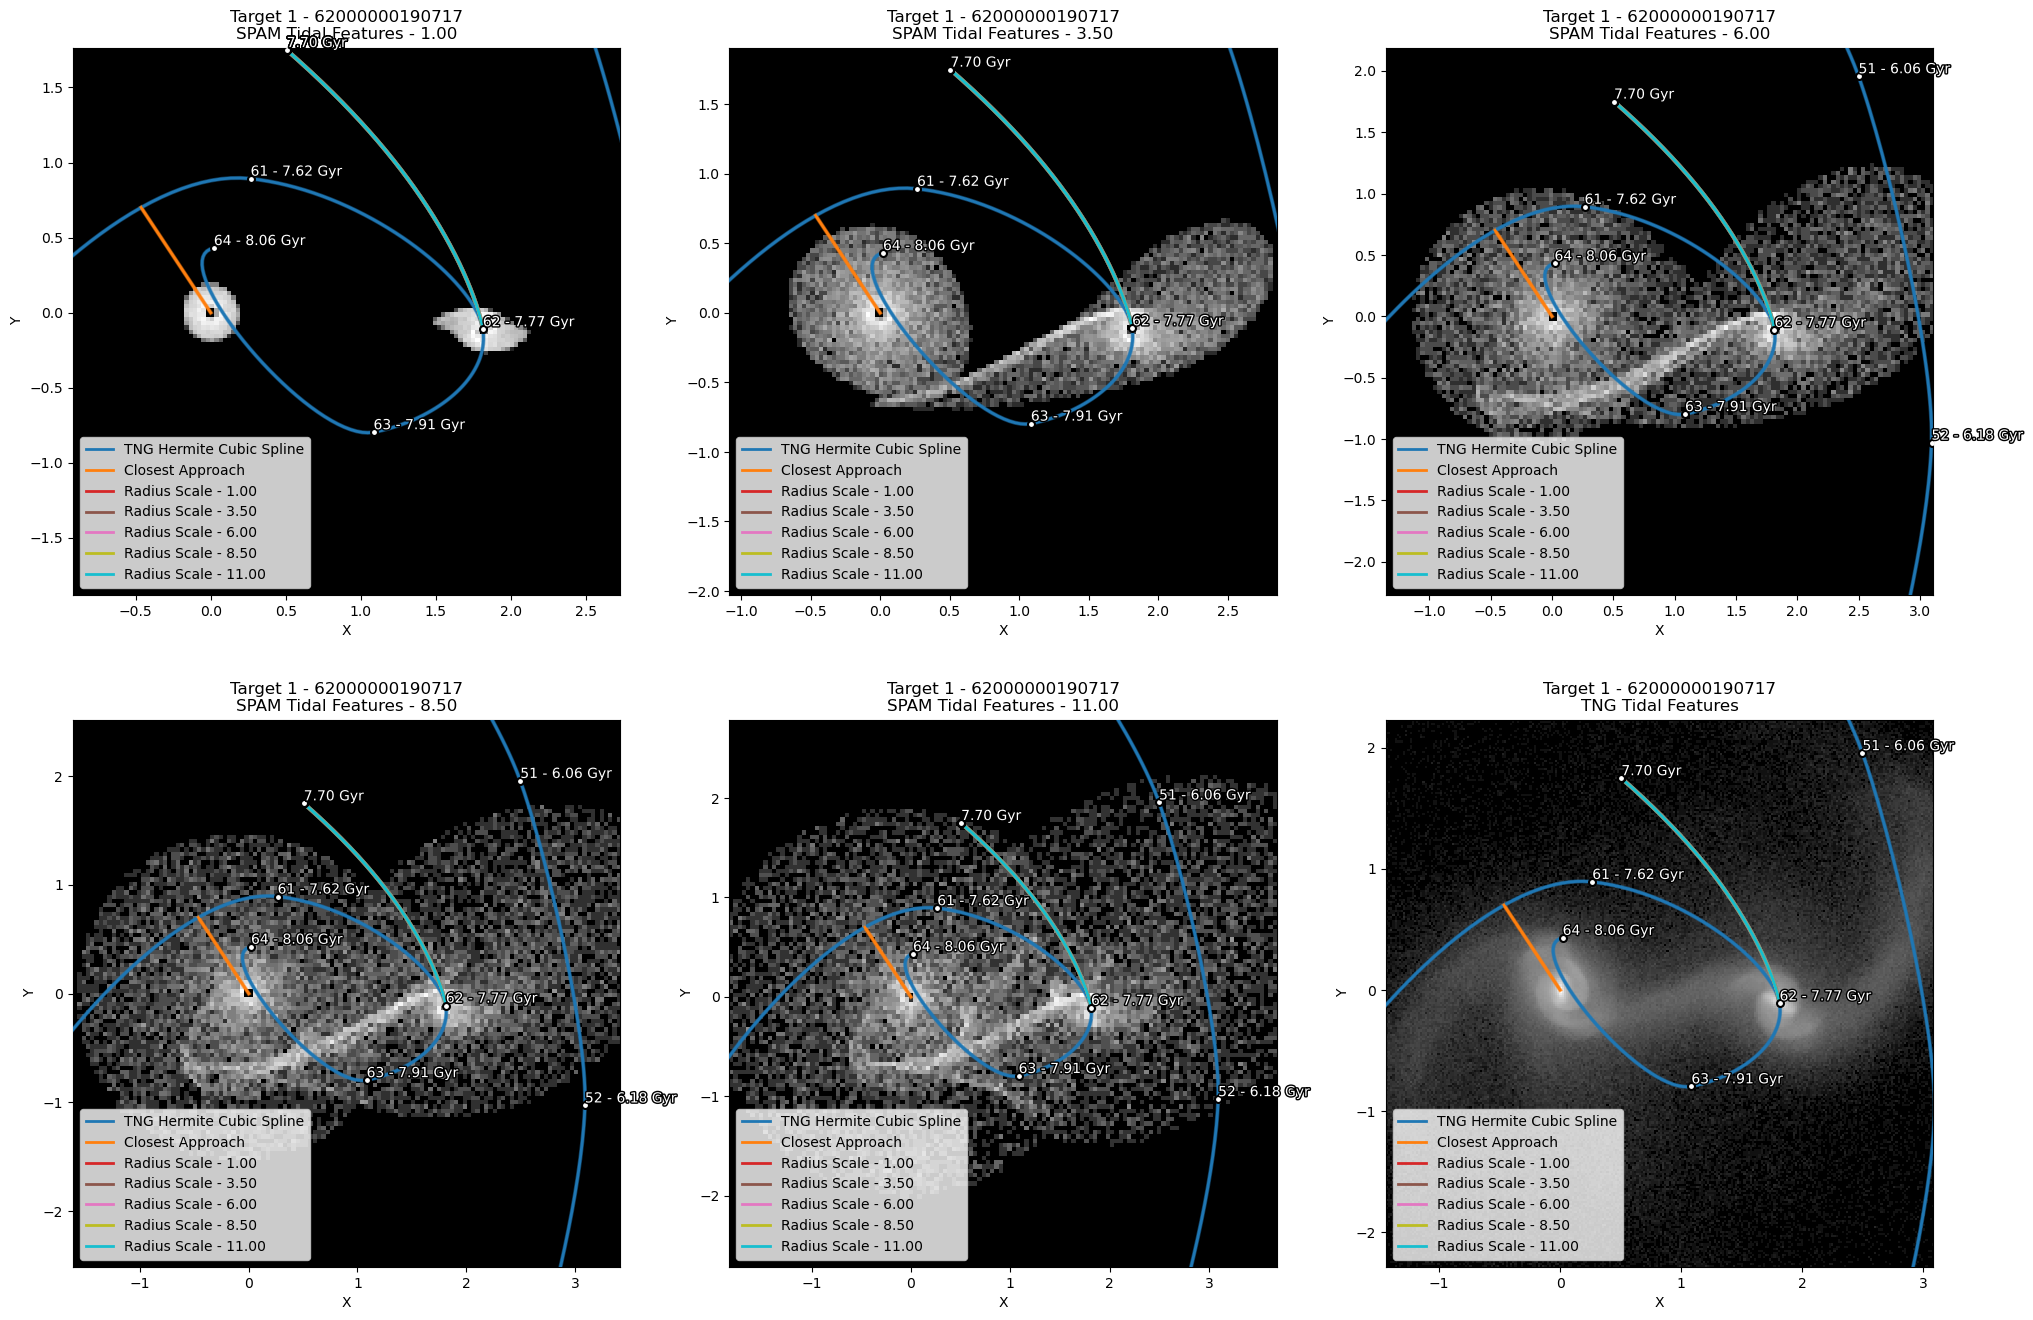
<center>
**Figure: Adjusting SPAM Radius** Scaling the TNG half mass radius up to see affects on tidal features.  Note, the orbits appear to perfectly overlap.  
</center>

# Comparing TNG to SPAM Analysis

So increasing the radius helped show off the tidal features, but it's fairly clear the tidal features DO NOT match up.  This is concerning, because SPAM is supposed to be able to recreate realistic tidal features of merging galaxies. 

## Point 1: Orbits are Off
 Increasing the radius did show more tidal features, however they the resulting SPAM tidal features do not match the TNG tidal features.  I suspect the tidal features are off because the orbits themselves are off.  Based on literature of merging galaxies, the orbit and galaxy dynamics at the moment of closest approach have a high impact on the tidal features.  Thus, adjusting the orbit until it overlaps the tng orbit could create most closely matching tidal features.   **HOWEVER**, we do **NOT** want to change the TNG to SPAM parameters because those values are our control collision parameters (with exception to the TNG half mass radius).  This work is meant to prove SPAM can create tidal features similar to those of more computationally expensive merging simulations.  Thus we need to adjust other parameters.

It also happens that the SPAM simulation has some hyper parameters that are hardcoded.  For instance, there exists a 'lnl' parameter for affecting how strong the dynamical friction is. This was hardcoded during Galaxy Zoo: Mergers, so I've gone ahead and made this an adjustable variable.  Another set of variables I can change is the "unit disk galaxy" SPAM uses.  Based on observations of the Milky Way, SPAM hardcodes the size and mass ratios between the galactic bulge, disk and dark matter halo.  However, more recent literature indicates the dark matter halo could be much larger than previously thought.  Thus, I went ahead and made these variables adjustable as well. 

 **Note about Radius**: The TNG radius is a half mass radius, and the SPAM radius is for the disk of stars.  While they are likely a scale value of one another, I do not know that scale yet and may need to manually adjust this value when I have tidal features to compare.  Alternatively, I could download the particles for these galaxies before they have tidal features, and adjust the radius until the two disks overlap well.  

 ### FUTURE TASK:  Find TNG to SPAM Radius scale
  1) Download TNG particles at previous snapshot. 
  2) Modify radius scale up and down
  3) Find radius scale where disks appear to overlap well
  4) Could use 2D correlation to quantify how well they match.  

## Point 2:  The radius does NOT affect the orbit, only particle distribution.  
Up until this point, I had assumed the radius of the two galaxies would scale up or down the "unit galaxy" SPAM uses to calculate particle acceleration.  However, while changing the radius for the figure above, we can see the orbits all seem to perfectly overlap one another.  I looked deeper into the code of SPAM and verified that while the masses of the two galaxies will affect the strength of acceleration, the radius does **NOT**.    This is concerning, because while experimenting with the radius of the dark matter halo of the SPAM unit galaxy (see figures below), the orbit is definitely affected.  Which makes sense, at this scale the two galaxies are likely traveling through the other's dark matter halo, which would affect accelerations.  This means the size of the unit galaxy SPAM uses to calculate accelerations is set.  While I can change the size and mass ratios of this unit galaxy, I cannot scale their size up and down for each galaxy.  Thus if I have two merging galaxies of very different sizes, SPAM may not recreate their tidal features as well.  At some point in the future I may modify the SPAM code to either scale the strength of acceleration based on a radius value, or do a more intense modification and have it generate two unit galaxies. 

### FUTURE TASK: Have galaxy radii affect acceleration:
1) Scale acceleration based on particle location within dark matter halo of other galaxy.
2) Generate two potential matrices, one for each galaxy.  

---
---

---
---
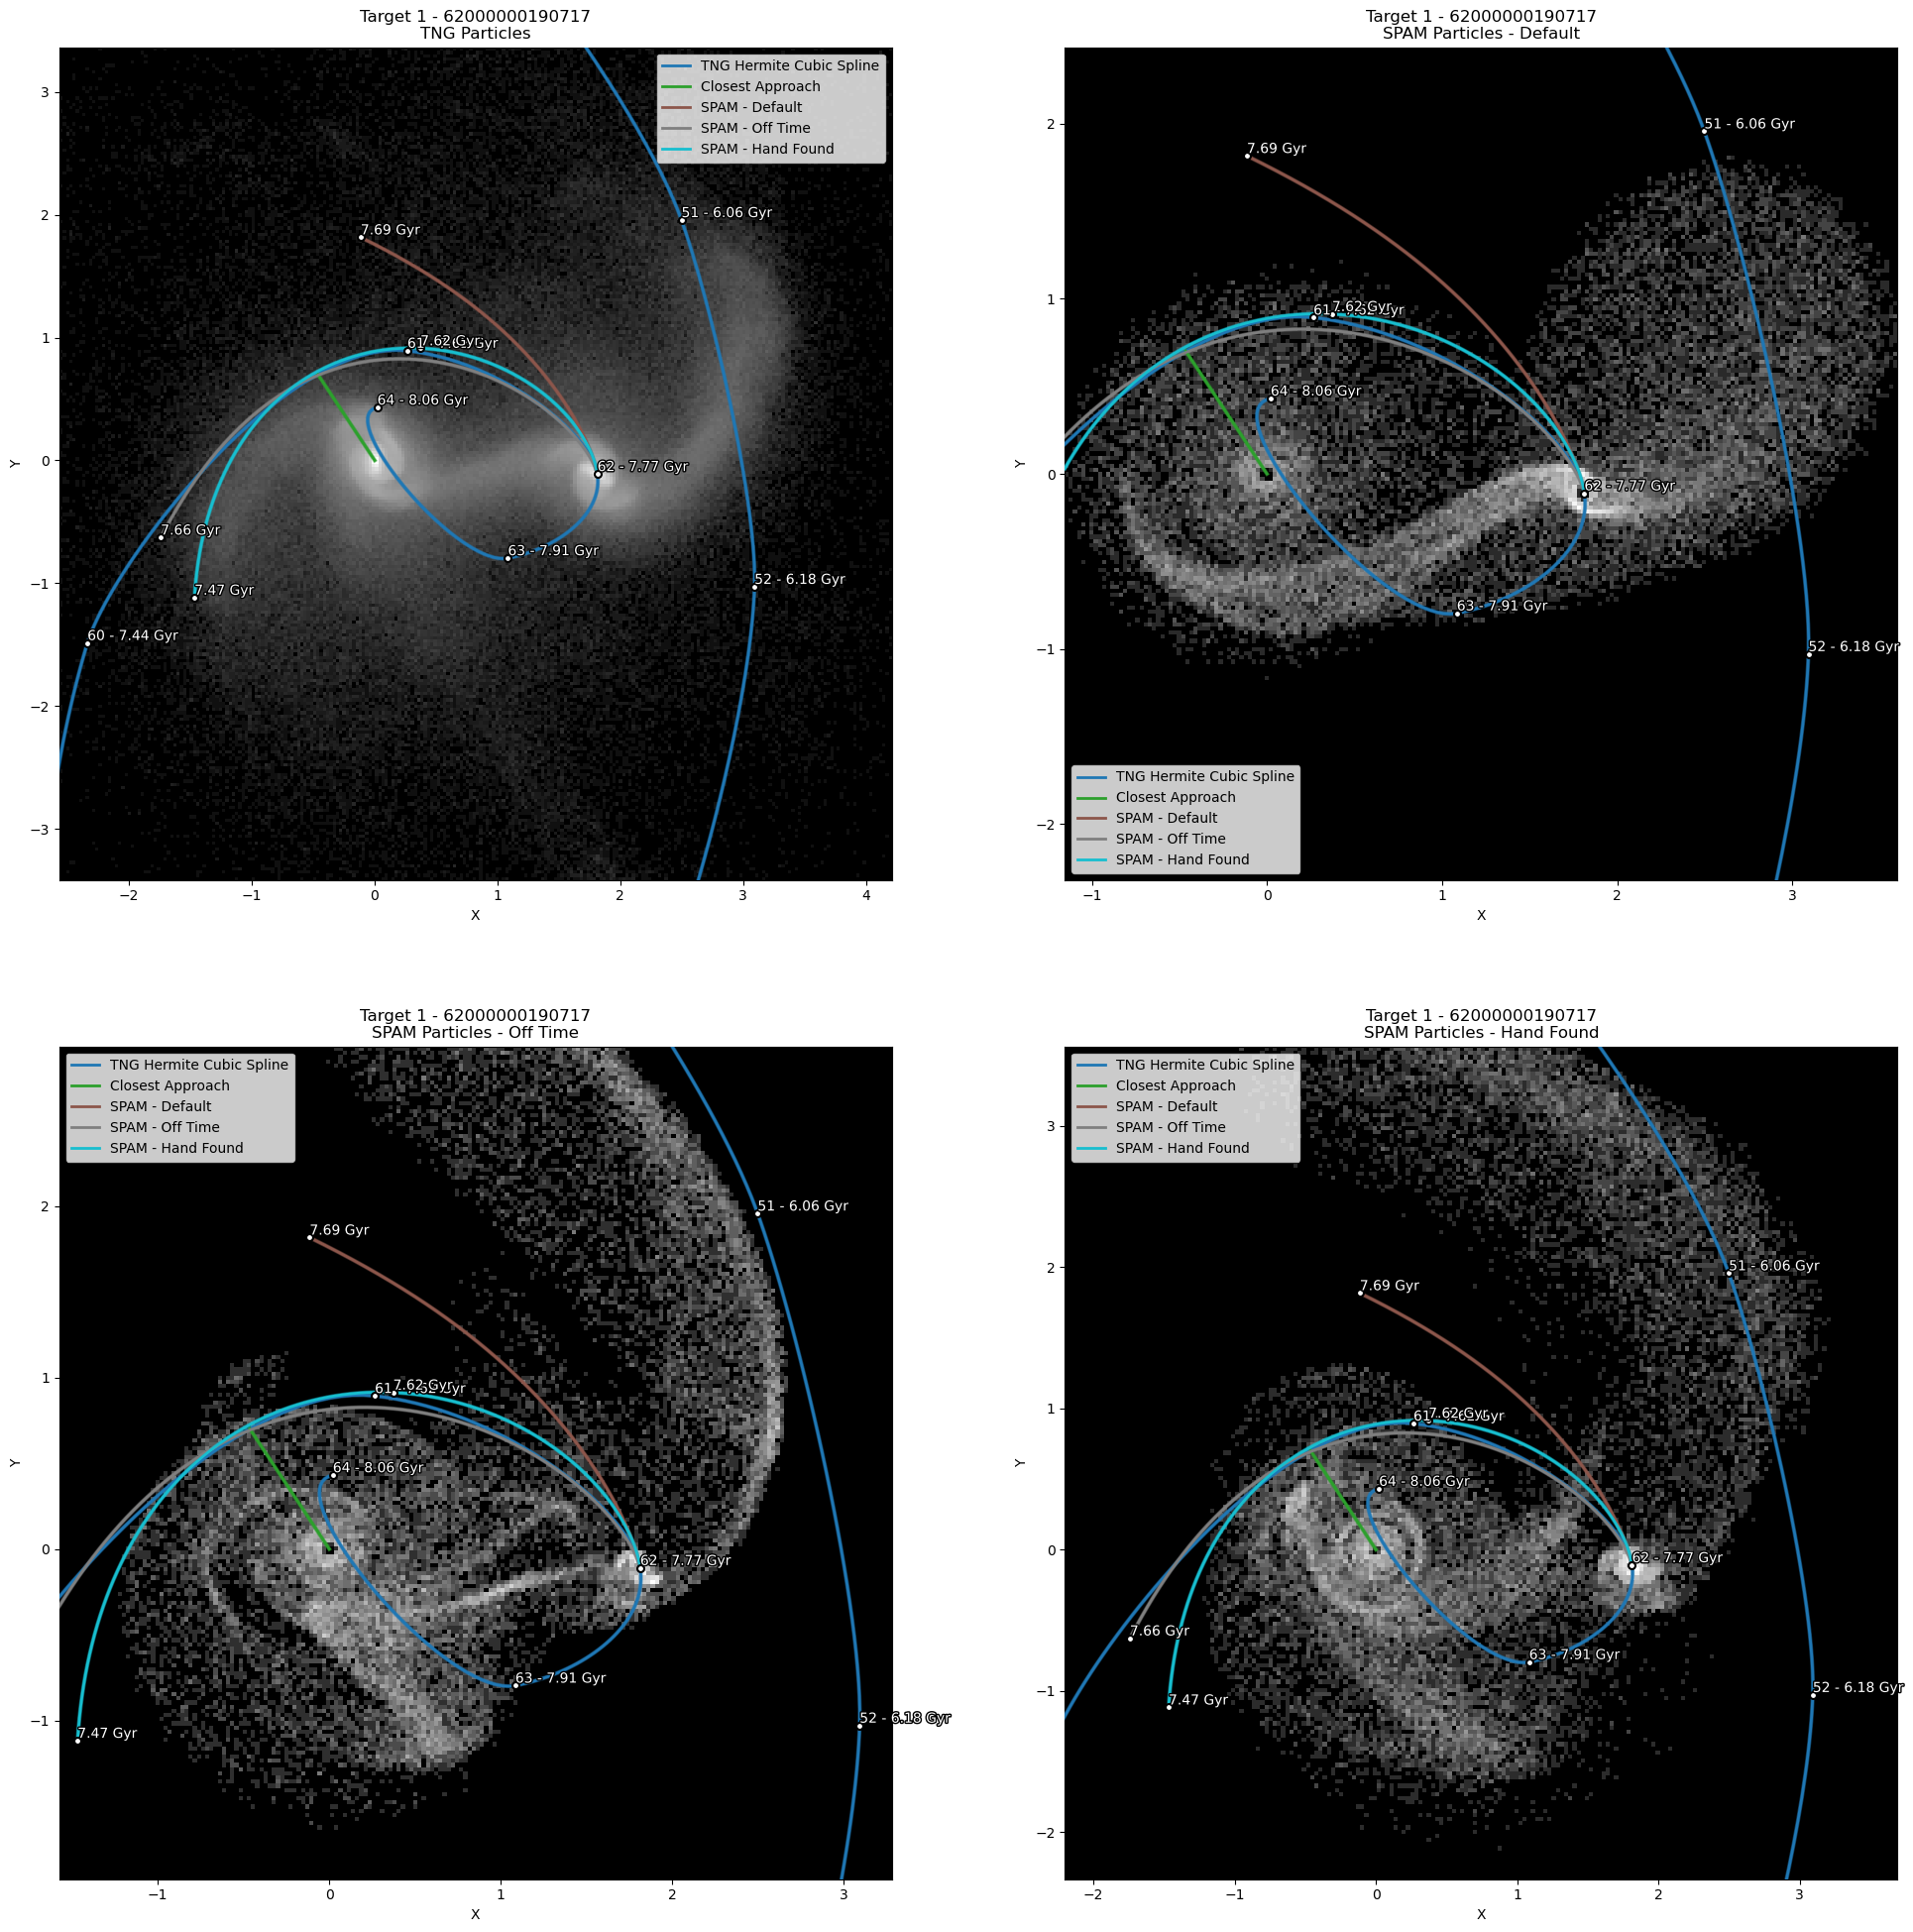
<center>
Figure: SPAM Tidal Features of Overlapping Orbits.
</center>

# Wonderful Success!

As suspected, by adjusting the SPAM hyperparameters, we can get the orbits to overlaps.  Once they overlap, several major tidal features begin to form that closely match the TNG tidal features.  This is a huge success and shows that SPAM can simulate the tidal features of colliding galaxies.  Why they are note perfect, these orbits were found by hand, and using an optimization function could likely find better solutions/orbits.  Do note, I found two orbits that overlap well at the moment of closest approach.  However, if you look at the starting times for their orbits, you'll note they have very different times.  One of them is moving much faster than the other, yet both produced tidal features that resemble the TNG tidal features.

---
---
# OKAY MATTHEW, END SCRIPT

So I *had* an entire 2nd half to this notebook that's all about creating orbit fitness functions and doing a gridsearch of the SPAM parameters, then the beginnings of an optimization program (And fixings bugs after *hours* of  compuations).  But the notebook got FAR too long (1900 ish lines here).  And I started getting overwhelmed trying to scroll up and down, making edits, and rerunning everything; so I'm going to end this here.  I am making a new script for tuning the SPAM Simulation Parameters within the Simulation Directory.